# Facilities Inspection Agent

An LLM-powered facilities inspection workflow that converts natural-language field observations into standardized inspection records, identifies missing information, supports human review and correction, generates maintenance work orders, and produces building-level analytics.

## Core Capabilities

- Natural-language inspection processing
- Structured LLM extraction
- Missing-information detection
- Follow-up interactions
- Human editing and confirmation
- Deterministic maintenance and priority rules
- Duplicate protection
- Persistent inspection storage
- Automatic maintenance work-order generation
- Work-order status tracking
- Building-level analytics and visualizations

# Facilities Inspection AI Prototype

## Project Goal
Create an AI-assisted facilities inspection system that converts natural-language
inspection notes into standardized, structured documentation.

## Inspection Record Fields
- Building
- Room
- Occupancy Status
- Carpet Condition
- Furniture Condition
- Cleanliness
- Safety Issue
- Maintenance Required
- Priority
- Original Notes
- Standardized Summary

## Design Rule
The system should never assume a condition that the inspector did not explicitly
observe. Missing information should be recorded as "Unknown."

## 1. Define Inspection Record Structure

This section defines the information the system should extract from each facilities inspection, along with the standardized values allowed for each field.

## Allowed Values

### Occupancy Status
- Vacant
- Occupied
- Unknown

### Carpet Condition
- Good
- Stained
- Damaged
- Unknown

### Furniture Condition
- Good
- Minor Issue
- Damaged
- Missing
- Unknown

### Cleanliness
- Clean
- Acceptable
- Needs Cleaning
- Unknown

### Safety Issue
- None
- Issue Identified
- Unknown

### Priority
- Low
- Medium
- High

## 2. Create Test Inspection Notes

This section creates sample facilities inspection notes that will be used to test whether the AI can correctly interpret and standardize natural-language observations.

In [ ]:
inspection_notes = [
    "FSK 203 vacant. Carpet looks good. Desk and bed are in good condition. No safety issues.",

    "FSK 306 vacant. Carpet ripped near the door. Closet door will not close properly.",

    "FSK 410 vacant. Smoke detector is hanging from the ceiling and the desk is damaged.",

    "FSK 504 occupied. Room appears clean and no maintenance issues were noticed.",

    "FSK 610 vacant. Carpet is heavily stained, room needs cleaning, and one chair is missing.",

    "FSK 211 vacant. Carpet looks good but the desk drawer is broken.",

    "FSK 312 occupied. No problems noticed during inspection.",

    "FSK 404 vacant. Room is clean, furniture looks good, but carpet has a small stain near the bed.",

    "FSK 505 vacant. Bed frame is damaged and there is a loose electrical outlet near the desk.",

    "FSK 207 vacant. Room needs cleaning. Carpet and furniture appear to be in good condition."
]

In [ ]:
inspection_notes.append(
    "FSK 412 vacant. Carpet stained near the window."
)

In [ ]:
for note in inspection_notes:
    print(note)

FSK 203 vacant. Carpet looks good. Desk and bed are in good condition. No safety issues.
FSK 306 vacant. Carpet ripped near the door. Closet door will not close properly.
FSK 410 vacant. Smoke detector is hanging from the ceiling and the desk is damaged.
FSK 504 occupied. Room appears clean and no maintenance issues were noticed.
FSK 610 vacant. Carpet is heavily stained, room needs cleaning, and one chair is missing.
FSK 211 vacant. Carpet looks good but the desk drawer is broken.
FSK 312 occupied. No problems noticed during inspection.
FSK 404 vacant. Room is clean, furniture looks good, but carpet has a small stain near the bed.
FSK 505 vacant. Bed frame is damaged and there is a loose electrical outlet near the desk.
FSK 207 vacant. Room needs cleaning. Carpet and furniture appear to be in good condition.
FSK 412 vacant. Carpet stained near the window.


In [ ]:
!pip install openai

## 3. Connect to the OpenAI API

This section securely retrieves the OpenAI API key from Google Colab Secrets and creates an API client that can communicate with the language model.

In [ ]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get("OPENAI_API_KEY")
)

## 4. Select an Inspection Note for Testing

This section selects one sample inspection note to test the AI extraction process.

In [ ]:
test_note = inspection_notes[-1]

print(test_note)

FSK 412 vacant. Carpet stained near the window.


## 5. Convert Inspection Notes into Structured JSON

This section sends a natural-language inspection note to the LLM and asks it to extract the information into a standardized JSON format.

In [ ]:
response = client.responses.create(
    model="gpt-6-astra",
    instructions="""
You are a facilities inspection documentation assistant.

Convert the inspector's natural-language notes into standardized inspection data.

Rules:
- Use only information explicitly provided by the inspector.
- Do not assume that something is in good condition if it was not mentioned.
- If a condition was not observed or mentioned, record it as "Unknown".
- Use only the allowed values listed below.

Allowed values:

Occupancy Status:
- Vacant
- Occupied
- Unknown

Carpet Condition:
- Good
- Stained
- Damaged
- Unknown

Furniture Condition:
- Good
- Minor Issue
- Damaged
- Missing
- Unknown

Cleanliness:
- Clean
- Acceptable
- Needs Cleaning
- Unknown

Safety Issue:
- None
- Issue Identified
- Unknown

Return ONLY valid JSON.
""",
    input=f"""
Inspection note:

{test_note}

Return JSON with exactly these fields:

building
room
occupancy_status
carpet_condition
furniture_condition
cleanliness
safety_issue
summary
"""
)

print(response.output_text)

{
  "building": "FSK",
  "room": "412",
  "occupancy_status": "Vacant",
  "carpet_condition": "Stained",
  "furniture_condition": "Unknown",
  "cleanliness": "Unknown",
  "safety_issue": "Unknown",
  "summary": "FSK 412 is vacant. Carpet is stained near the window."
}


## 6. Convert the AI Response into a Python Dictionary

This section converts the JSON response from the AI into a Python dictionary so individual inspection fields can be accessed and processed programmatically.

In [ ]:
import json

record = json.loads(response.output_text)

print(record)

{'building': 'FSK', 'room': '412', 'occupancy_status': 'Vacant', 'carpet_condition': 'Stained', 'furniture_condition': 'Unknown', 'cleanliness': 'Unknown', 'safety_issue': 'Unknown', 'summary': 'FSK 412 is vacant. Carpet is stained near the window.'}


## 7. Access Individual Inspection Fields

This section confirms that individual values can be retrieved from the structured inspection record.

In [ ]:
print(record["building"])
print(record["room"])
print(record["carpet_condition"])

FSK
412
Stained


## 8. Define Valid Inspection Values

This section defines the approved standardized values for each inspection field. These rules help prevent inconsistent or unexpected AI outputs.

In [ ]:
valid_occupancy = ["Vacant", "Occupied", "Unknown"]
valid_carpet = ["Good", "Stained", "Damaged", "Unknown"]
valid_furniture = ["Good", "Minor Issue", "Damaged", "Missing", "Unknown"]
valid_cleanliness = ["Clean", "Acceptable", "Needs Cleaning", "Unknown"]
valid_safety = ["None", "Issue Identified", "Unknown"]

## 9. Validate the Inspection Record

This section checks whether the values produced by the AI match the standardized inspection categories.

In [ ]:
if record["occupancy_status"] not in valid_occupancy:
    print("Invalid occupancy status")

if record["carpet_condition"] not in valid_carpet:
    print("Invalid carpet condition")

if record["furniture_condition"] not in valid_furniture:
    print("Invalid furniture condition")

if record["cleanliness"] not in valid_cleanliness:
    print("Invalid cleanliness value")

if record["safety_issue"] not in valid_safety:
    print("Invalid safety value")

## 10. Create a Reusable Validation Function

This function automatically checks each inspection record for invalid values and returns any validation errors that are found.

In [ ]:
def validate_record(record):
    errors = []

    if record["occupancy_status"] not in valid_occupancy:
        errors.append("Invalid occupancy status")

    if record["carpet_condition"] not in valid_carpet:
        errors.append("Invalid carpet condition")

    if record["furniture_condition"] not in valid_furniture:
        errors.append("Invalid furniture condition")

    if record["cleanliness"] not in valid_cleanliness:
        errors.append("Invalid cleanliness value")

    if record["safety_issue"] not in valid_safety:
        errors.append("Invalid safety value")

    return errors

### Test the Validation Function

This test confirms whether the current inspection record passes all standardized validation rules.

In [ ]:
errors = validate_record(record)

if len(errors) == 0:
    print("Record is valid.")
else:
    print("Validation errors:")
    for error in errors:
        print("-", error)

Record is valid.


## 11. Determine Whether Maintenance Is Required

This function uses consistent Python rules to determine whether an inspection requires maintenance follow-up. The decision is based on the structured conditions identified by the AI rather than allowing the AI to make the final decision itself.

In [ ]:
def determine_maintenance(record):
    if record["carpet_condition"] in ["Stained", "Damaged"]:
        return True

    if record["furniture_condition"] in ["Minor Issue", "Damaged", "Missing"]:
        return True

    if record["cleanliness"] == "Needs Cleaning":
        return True

    if record["safety_issue"] == "Issue Identified":
        return True

    return False

### Apply the Maintenance Rule

This step applies the maintenance function to the current inspection record and stores the result as a new field.

In [ ]:
record["maintenance_required"] = determine_maintenance(record)

print(record["maintenance_required"])

True


## 12. Assign a Maintenance Priority

This function assigns a Low, Medium, or High priority to an inspection record based on the type and severity of the issue identified.

Priority is determined using consistent Python rules rather than allowing the AI to decide independently.

In [ ]:
def determine_priority(record):
    # High priority for safety issues
    if record["safety_issue"] == "Issue Identified":
        return "High"

    # Medium priority for damaged or missing items
    if record["carpet_condition"] == "Damaged":
        return "Medium"

    if record["furniture_condition"] in ["Damaged", "Missing"]:
        return "Medium"

    # Low priority for minor maintenance or cleaning issues
    if record["carpet_condition"] == "Stained":
        return "Low"

    if record["furniture_condition"] == "Minor Issue":
        return "Low"

    if record["cleanliness"] == "Needs Cleaning":
        return "Low"

    # No maintenance issue identified
    return "None"

### Apply the Priority Rule

This step applies the priority function to the current inspection record and stores the result in the structured record.

In [ ]:
record["priority"] = determine_priority(record)

print(record["priority"])

Low


## 13. Display the Complete Processed Inspection Record

This section displays the final structured inspection record in a readable table after AI extraction, validation, maintenance determination, and priority assignment have been completed.

In [ ]:
import pandas as pd

record_df = pd.DataFrame([record])

record_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,maintenance_required,priority
0,FSK,412,Vacant,Stained,Unknown,Unknown,Unknown,FSK 412 is vacant. Carpet is stained near the ...,True,Low


### Organize the Inspection Record

This step arranges the inspection fields in a logical order so the completed record is easier to review.

In [ ]:
column_order = [
    "building",
    "room",
    "occupancy_status",
    "carpet_condition",
    "furniture_condition",
    "cleanliness",
    "safety_issue",
    "maintenance_required",
    "priority",
    "summary"
]

record_df = record_df[column_order]

record_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,maintenance_required,priority,summary
0,FSK,412,Vacant,Stained,Unknown,Unknown,Unknown,True,Low,FSK 412 is vacant. Carpet is stained near the ...


## 14. Create a Reusable Inspection Processing Function

This function combines the major steps of the workflow into one process. It sends a natural-language inspection note to the LLM, converts the response into structured data, validates the record, determines whether maintenance is required, and assigns a priority level.

### Improve Safety-Issue Classification

Based on the holdout evaluation, the extraction instructions are refined to distinguish between an unobserved safety condition ("Unknown") and a safety item that was explicitly inspected and found to be normal ("None").

In [ ]:
def process_inspection(note):

    # Step 1: Send the inspection note to the LLM
    response = client.responses.create(
        model="gpt-6-astra",
        instructions="""
You are a facilities inspection documentation assistant.

Convert the inspector's natural-language notes into standardized inspection data.

Rules:
- Use only information explicitly provided by the inspector.
- Do not assume something is in good condition if it was not mentioned.
- If a condition was not observed or mentioned, record it as "Unknown".
- If a safety item is explicitly observed and described as normal, functional, okay, or having no concern, classify Safety Issue as "None".
- Use "Unknown" for Safety Issue only when safety conditions were not observed or not mentioned.
- Use only the allowed values listed below.

Allowed values:

Occupancy Status:
- Vacant
- Occupied
- Unknown

Carpet Condition:
- Good
- Stained
- Damaged
- Unknown

Furniture Condition:
- Good
- Minor Issue
- Damaged
- Missing
- Unknown

Cleanliness:
- Clean
- Acceptable
- Needs Cleaning
- Unknown

Safety Issue:
- None
- Issue Identified
- Unknown

Return ONLY valid JSON.
""",
        input=f"""
Inspection note:

{note}

Return JSON with exactly these fields:

building
room
occupancy_status
carpet_condition
furniture_condition
cleanliness
safety_issue
summary
"""
    )

    # Step 2: Convert the JSON response into a Python dictionary
    record = json.loads(response.output_text)

    # Preserve the original inspection note
    record["original_notes"] = note

    # Step 3: Validate the record
    errors = validate_record(record)

    if len(errors) > 0:
        print("Validation errors:")
        for error in errors:
            print("-", error)

    # Step 4: Determine whether maintenance is required
    record["maintenance_required"] = determine_maintenance(record)

    # Step 5: Assign a maintenance priority
    record["priority"] = determine_priority(record)

    return record

### Test the Reusable Processing Function

This test confirms that the complete workflow can process a new inspection note automatically from beginning to end.

In [ ]:
test_record = process_inspection(inspection_notes[0])

print(test_record)

{'building': 'FSK', 'room': '203', 'occupancy_status': 'Vacant', 'carpet_condition': 'Good', 'furniture_condition': 'Good', 'cleanliness': 'Unknown', 'safety_issue': 'None', 'summary': 'FSK 203 is vacant. Carpet, desk, and bed are in good condition. No safety issues. Cleanliness was not mentioned.', 'maintenance_required': False, 'priority': 'None'}


## 15. Process All Test Inspection Notes

This section applies the reusable inspection-processing function to every sample inspection note. Each note is converted into a standardized record and stored for later analysis.

In [ ]:
processed_records = []

for note in inspection_notes:
    record = process_inspection(note)
    processed_records.append(record)

### Convert Processed Records into a DataFrame

This step combines all processed inspection records into one structured dataset so they can be reviewed and analyzed together.

In [ ]:
inspection_df = pd.DataFrame(processed_records)

inspection_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,203,Vacant,Good,Good,Unknown,None,"FSK 203 is vacant. Carpet, desk, and bed are i...",FSK 203 vacant. Carpet looks good. Desk and be...,False,None
1,FSK,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,Room is vacant. Carpet is ripped near the door...,FSK 306 vacant. Carpet ripped near the door. C...,True,Medium
2,FSK,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,Room is vacant. Smoke detector is hanging from...,FSK 410 vacant. Smoke detector is hanging from...,True,High
3,FSK,504,Occupied,Unknown,Unknown,Clean,Unknown,Room is occupied and appears clean. No mainten...,FSK 504 occupied. Room appears clean and no ma...,False,None
4,FSK,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,"Room is vacant. Carpet is heavily stained, the...","FSK 610 vacant. Carpet is heavily stained, roo...",True,Medium
5,FSK,211,Vacant,Good,Damaged,Unknown,Unknown,"FSK 211 is vacant. The carpet looks good, but ...",FSK 211 vacant. Carpet looks good but the desk...,True,Medium
6,FSK,312,Occupied,Unknown,Unknown,Unknown,Unknown,Room occupied. No problems noticed during insp...,FSK 312 occupied. No problems noticed during i...,False,None
7,FSK,404,Vacant,Stained,Good,Clean,Unknown,Room is vacant and clean. Furniture looks good...,"FSK 404 vacant. Room is clean, furniture looks...",True,Low
8,FSK,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,"Room is vacant. The bed frame is damaged, and ...",FSK 505 vacant. Bed frame is damaged and there...,True,High
9,FSK,207,Vacant,Good,Good,Needs Cleaning,Unknown,Room is vacant and needs cleaning. Carpet and ...,FSK 207 vacant. Room needs cleaning. Carpet an...,True,Low


### Organize the Final Inspection Dataset

This step arranges the dataset columns in a consistent and readable order.

In [ ]:
column_order = [
    "building",
    "room",
    "occupancy_status",
    "carpet_condition",
    "furniture_condition",
    "cleanliness",
    "safety_issue",
    "maintenance_required",
    "priority",
    "summary"
]

inspection_df = inspection_df[column_order]

inspection_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,maintenance_required,priority,summary
0,FSK,203,Vacant,Good,Good,Unknown,None,False,None,"FSK 203 is vacant. Carpet, desk, and bed are i..."
1,FSK,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,True,Medium,Room is vacant. Carpet is ripped near the door...
2,FSK,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,High,Room is vacant. Smoke detector is hanging from...
3,FSK,504,Occupied,Unknown,Unknown,Clean,Unknown,False,None,Room is occupied and appears clean. No mainten...
4,FSK,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,True,Medium,"Room is vacant. Carpet is heavily stained, the..."
5,FSK,211,Vacant,Good,Damaged,Unknown,Unknown,True,Medium,"FSK 211 is vacant. The carpet looks good, but ..."
6,FSK,312,Occupied,Unknown,Unknown,Unknown,Unknown,False,None,Room occupied. No problems noticed during insp...
7,FSK,404,Vacant,Stained,Good,Clean,Unknown,True,Low,Room is vacant and clean. Furniture looks good...
8,FSK,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,High,"Room is vacant. The bed frame is damaged, and ..."
9,FSK,207,Vacant,Good,Good,Needs Cleaning,Unknown,True,Low,Room is vacant and needs cleaning. Carpet and ...


## 16. Preserve the Original Inspection Notes

This section stores each inspector's original natural-language note alongside the standardized AI-generated record. Keeping the source text allows the extracted data to be reviewed for accuracy and provides an audit trail for each inspection.

### Reprocess Inspections with Original Notes

Now that the processing function preserves the original inspector notes, all sample inspections are processed again so the source text is included in each structured record.

In [ ]:
processed_records = []

for note in inspection_notes:
    record = process_inspection(note)
    processed_records.append(record)

inspection_df = pd.DataFrame(processed_records)

inspection_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,203,Vacant,Good,Good,Unknown,None,"Room FSK 203 is vacant. Carpet, desk, and bed ...",FSK 203 vacant. Carpet looks good. Desk and be...,False,None
1,FSK,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,Room is vacant. Carpet is ripped near the door...,FSK 306 vacant. Carpet ripped near the door. C...,True,Medium
2,FSK,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,Room FSK 410 is vacant. The smoke detector is ...,FSK 410 vacant. Smoke detector is hanging from...,True,High
3,FSK,504,Occupied,Unknown,Unknown,Clean,Unknown,Room is occupied and appears clean. No mainten...,FSK 504 occupied. Room appears clean and no ma...,False,None
4,FSK,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,Room FSK 610 is vacant. The carpet is heavily ...,"FSK 610 vacant. Carpet is heavily stained, roo...",True,Medium
5,FSK,211,Vacant,Good,Damaged,Unknown,Unknown,"FSK 211 is vacant. The carpet looks good, but ...",FSK 211 vacant. Carpet looks good but the desk...,True,Medium
6,FSK,312,Occupied,Unknown,Unknown,Unknown,Unknown,Room occupied. No problems noticed during insp...,FSK 312 occupied. No problems noticed during i...,False,None
7,FSK,404,Vacant,Stained,Good,Clean,Unknown,Room is vacant and clean. Furniture looks good...,"FSK 404 vacant. Room is clean, furniture looks...",True,Low
8,FSK,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,"Room is vacant. The bed frame is damaged, and ...",FSK 505 vacant. Bed frame is damaged and there...,True,High
9,FSK,207,Vacant,Good,Good,Needs Cleaning,Unknown,FSK 207 is vacant and needs cleaning. Carpet a...,FSK 207 vacant. Room needs cleaning. Carpet an...,True,Low


### Add Original Notes to the Final Dataset

This step places the original inspector note alongside the standardized AI-generated fields so the extracted information can be compared directly with the source text.


In [ ]:
column_order = [
    "building",
    "room",
    "occupancy_status",
    "carpet_condition",
    "furniture_condition",
    "cleanliness",
    "safety_issue",
    "maintenance_required",
    "priority",
    "original_notes",
    "summary"
]

inspection_df = inspection_df[column_order]

inspection_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,maintenance_required,priority,original_notes,summary
0,FSK,203,Vacant,Good,Good,Unknown,None,False,None,FSK 203 vacant. Carpet looks good. Desk and be...,"Room FSK 203 is vacant. Carpet, desk, and bed ..."
1,FSK,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,True,Medium,FSK 306 vacant. Carpet ripped near the door. C...,Room is vacant. Carpet is ripped near the door...
2,FSK,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,High,FSK 410 vacant. Smoke detector is hanging from...,Room FSK 410 is vacant. The smoke detector is ...
3,FSK,504,Occupied,Unknown,Unknown,Clean,Unknown,False,None,FSK 504 occupied. Room appears clean and no ma...,Room is occupied and appears clean. No mainten...
4,FSK,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,True,Medium,"FSK 610 vacant. Carpet is heavily stained, roo...",Room FSK 610 is vacant. The carpet is heavily ...
5,FSK,211,Vacant,Good,Damaged,Unknown,Unknown,True,Medium,FSK 211 vacant. Carpet looks good but the desk...,"FSK 211 is vacant. The carpet looks good, but ..."
6,FSK,312,Occupied,Unknown,Unknown,Unknown,Unknown,False,None,FSK 312 occupied. No problems noticed during i...,Room occupied. No problems noticed during insp...
7,FSK,404,Vacant,Stained,Good,Clean,Unknown,True,Low,"FSK 404 vacant. Room is clean, furniture looks...",Room is vacant and clean. Furniture looks good...
8,FSK,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,High,FSK 505 vacant. Bed frame is damaged and there...,"Room is vacant. The bed frame is damaged, and ..."
9,FSK,207,Vacant,Good,Good,Needs Cleaning,Unknown,True,Low,FSK 207 vacant. Room needs cleaning. Carpet an...,FSK 207 is vacant and needs cleaning. Carpet a...


## 17. Evaluate AI Extraction Accuracy

This section compares the AI-generated inspection fields with manually defined expected results. This provides a simple evaluation of how accurately the LLM converts natural-language inspection notes into standardized data.

### Define the Expected Results

The expected results represent the correct standardized values for each sample inspection based on the original notes. These values will be used as a benchmark for evaluating the AI output.

In [ ]:
expected_records = [
    ["203", "Vacant", "Good", "Good", "Unknown", "None"],
    ["306", "Vacant", "Damaged", "Minor Issue", "Unknown", "Unknown"],
    ["410", "Vacant", "Unknown", "Damaged", "Unknown", "Issue Identified"],
    ["504", "Occupied", "Unknown", "Unknown", "Clean", "Unknown"],
    ["610", "Vacant", "Stained", "Missing", "Needs Cleaning", "Unknown"],
    ["211", "Vacant", "Good", "Damaged", "Unknown", "Unknown"],
    ["312", "Occupied", "Unknown", "Unknown", "Unknown", "Unknown"],
    ["404", "Vacant", "Stained", "Good", "Clean", "Unknown"],
    ["505", "Vacant", "Unknown", "Damaged", "Unknown", "Issue Identified"],
    ["207", "Vacant", "Good", "Good", "Needs Cleaning", "Unknown"],
    ["412", "Vacant", "Stained", "Unknown", "Unknown", "Unknown"]
]

expected_df = pd.DataFrame(
    expected_records,
    columns=[
        "room",
        "occupancy_status",
        "carpet_condition",
        "furniture_condition",
        "cleanliness",
        "safety_issue"
    ]
)

expected_df

,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue
0,203,Vacant,Good,Good,Unknown,None
1,306,Vacant,Damaged,Minor Issue,Unknown,Unknown
2,410,Vacant,Unknown,Damaged,Unknown,Issue Identified
3,504,Occupied,Unknown,Unknown,Clean,Unknown
4,610,Vacant,Stained,Missing,Needs Cleaning,Unknown
5,211,Vacant,Good,Damaged,Unknown,Unknown
6,312,Occupied,Unknown,Unknown,Unknown,Unknown
7,404,Vacant,Stained,Good,Clean,Unknown
8,505,Vacant,Unknown,Damaged,Unknown,Issue Identified
9,207,Vacant,Good,Good,Needs Cleaning,Unknown


### Compare AI Results with Expected Results

This section compares the AI-generated inspection values with the manually defined expected values for each room. The comparison is used to measure how accurately the LLM standardized the inspection notes.

In [ ]:
fields_to_compare = [
    "occupancy_status",
    "carpet_condition",
    "furniture_condition",
    "cleanliness",
    "safety_issue"
]

comparison_df = inspection_df[
    ["room"] + fields_to_compare
].copy()

for field in fields_to_compare:
    comparison_df[field + "_correct"] = (
        comparison_df[field].values == expected_df[field].values
    )

comparison_df

,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,occupancy_status_correct,carpet_condition_correct,furniture_condition_correct,cleanliness_correct,safety_issue_correct
0,203,Vacant,Good,Good,Unknown,None,True,True,True,True,True
1,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,True,True,True,True,True
2,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,True,True,True,True
3,504,Occupied,Unknown,Unknown,Clean,Unknown,True,True,True,True,True
4,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,True,True,True,True,True
5,211,Vacant,Good,Damaged,Unknown,Unknown,True,True,True,True,True
6,312,Occupied,Unknown,Unknown,Unknown,Unknown,True,True,True,True,True
7,404,Vacant,Stained,Good,Clean,Unknown,True,True,True,True,True
8,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,True,True,True,True
9,207,Vacant,Good,Good,Needs Cleaning,Unknown,True,True,True,True,True


### Match Expected and AI Results by Room

This step joins the AI-generated results with the expected results using the room number. Matching records by room makes the evaluation more reliable if the dataset order changes.

In [ ]:
evaluation_df = inspection_df[
    ["room"] + fields_to_compare
].merge(
    expected_df,
    on="room",
    suffixes=("_ai", "_expected")
)

for field in fields_to_compare:
    evaluation_df[field + "_correct"] = (
        evaluation_df[field + "_ai"] == evaluation_df[field + "_expected"]
    )

evaluation_df

,room,occupancy_status_ai,carpet_condition_ai,furniture_condition_ai,cleanliness_ai,safety_issue_ai,occupancy_status_expected,carpet_condition_expected,furniture_condition_expected,cleanliness_expected,safety_issue_expected,occupancy_status_correct,carpet_condition_correct,furniture_condition_correct,cleanliness_correct,safety_issue_correct
0,203,Vacant,Good,Good,Unknown,None,Vacant,Good,Good,Unknown,None,True,True,True,True,True
1,306,Vacant,Damaged,Minor Issue,Unknown,Unknown,Vacant,Damaged,Minor Issue,Unknown,Unknown,True,True,True,True,True
2,410,Vacant,Unknown,Damaged,Unknown,Issue Identified,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,True,True,True,True
3,504,Occupied,Unknown,Unknown,Clean,Unknown,Occupied,Unknown,Unknown,Clean,Unknown,True,True,True,True,True
4,610,Vacant,Stained,Missing,Needs Cleaning,Unknown,Vacant,Stained,Missing,Needs Cleaning,Unknown,True,True,True,True,True
5,211,Vacant,Good,Damaged,Unknown,Unknown,Vacant,Good,Damaged,Unknown,Unknown,True,True,True,True,True
6,312,Occupied,Unknown,Unknown,Unknown,Unknown,Occupied,Unknown,Unknown,Unknown,Unknown,True,True,True,True,True
7,404,Vacant,Stained,Good,Clean,Unknown,Vacant,Stained,Good,Clean,Unknown,True,True,True,True,True
8,505,Vacant,Unknown,Damaged,Unknown,Issue Identified,Vacant,Unknown,Damaged,Unknown,Issue Identified,True,True,True,True,True
9,207,Vacant,Good,Good,Needs Cleaning,Unknown,Vacant,Good,Good,Needs Cleaning,Unknown,True,True,True,True,True


### Calculate Overall Extraction Accuracy

This step calculates the percentage of standardized inspection fields that the AI extracted correctly after matching AI-generated records with expected results by room number.

In [ ]:
correct_columns = [
    field + "_correct" for field in fields_to_compare
]

total_correct = evaluation_df[correct_columns].sum().sum()
total_checks = len(evaluation_df) * len(fields_to_compare)

accuracy = total_correct / total_checks * 100

print("Correct fields:", total_correct)
print("Total fields checked:", total_checks)
print(f"Overall extraction accuracy: {accuracy:.1f}%")

Correct fields: 55
Total fields checked: 55
Overall extraction accuracy: 100.0%


## 18. Create a Harder Holdout Evaluation Set

This section creates a second set of inspection notes with more realistic and challenging wording. These examples are kept separate from the original development cases so they can be used to test how well the AI workflow generalizes to new inspection notes.

In [ ]:
holdout_notes = [
    "FSK 301 vacant. Carpet is fine. Desk has a cracked drawer. No safety concerns observed.",

    "FSK 315 occupied. Room needs cleaning. Furniture appears okay. Carpet was not checked.",

    "FSK 418 vacant. Loose electrical outlet by the bed. Everything else was not documented.",

    "FSK 502 empty. Carpet badly torn near doorway, chair missing, room is clean.",

    "FSK 516 occupied. No issues with carpet or furniture. Room appears clean. No safety concerns.",

    "FSK 602 vacant. Bed frame slightly loose but still usable. Carpet looks good.",

    "FSK 615 vacant. Strong stain on carpet. Smoke detector appears normal. Room needs cleaning.",

    "FSK 703 occupied. Inspector only confirmed occupancy; no other conditions were recorded."
]

for note in holdout_notes:
    print(note)

FSK 301 vacant. Carpet is fine. Desk has a cracked drawer. No safety concerns observed.
FSK 315 occupied. Room needs cleaning. Furniture appears okay. Carpet was not checked.
FSK 418 vacant. Loose electrical outlet by the bed. Everything else was not documented.
FSK 502 empty. Carpet badly torn near doorway, chair missing, room is clean.
FSK 516 occupied. No issues with carpet or furniture. Room appears clean. No safety concerns.
FSK 602 vacant. Bed frame slightly loose but still usable. Carpet looks good.
FSK 615 vacant. Strong stain on carpet. Smoke detector appears normal. Room needs cleaning.
FSK 703 occupied. Inspector only confirmed occupancy; no other conditions were recorded.


### Define Expected Results for the Holdout Set

These manually defined results represent the expected standardized interpretation of each new inspection note. They will serve as the benchmark for evaluating the AI on previously unseen examples.

In [ ]:
holdout_expected_records = [
    ["301", "Vacant", "Good", "Damaged", "Unknown", "None"],
    ["315", "Occupied", "Unknown", "Good", "Needs Cleaning", "Unknown"],
    ["418", "Vacant", "Unknown", "Unknown", "Unknown", "Issue Identified"],
    ["502", "Vacant", "Damaged", "Missing", "Clean", "Unknown"],
    ["516", "Occupied", "Good", "Good", "Clean", "None"],
    ["602", "Vacant", "Good", "Minor Issue", "Unknown", "Unknown"],
    ["615", "Vacant", "Stained", "Unknown", "Needs Cleaning", "None"],
    ["703", "Occupied", "Unknown", "Unknown", "Unknown", "Unknown"]
]

holdout_expected_df = pd.DataFrame(
    holdout_expected_records,
    columns=[
        "room",
        "occupancy_status",
        "carpet_condition",
        "furniture_condition",
        "cleanliness",
        "safety_issue"
    ]
)

holdout_expected_df

,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue
0,301,Vacant,Good,Damaged,Unknown,None
1,315,Occupied,Unknown,Good,Needs Cleaning,Unknown
2,418,Vacant,Unknown,Unknown,Unknown,Issue Identified
3,502,Vacant,Damaged,Missing,Clean,Unknown
4,516,Occupied,Good,Good,Clean,None
5,602,Vacant,Good,Minor Issue,Unknown,Unknown
6,615,Vacant,Stained,Unknown,Needs Cleaning,None
7,703,Occupied,Unknown,Unknown,Unknown,Unknown


### Process the Holdout Inspection Notes

This step sends each new holdout inspection note through the existing inspection-processing workflow. The same AI prompt, validation rules, maintenance rules, and priority rules are used without modification.

In [ ]:
holdout_processed_records = []

for note in holdout_notes:
    record = process_inspection(note)
    holdout_processed_records.append(record)

holdout_df = pd.DataFrame(holdout_processed_records)

holdout_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,301,Vacant,Good,Damaged,Unknown,None,Room is vacant. Carpet is in good condition. D...,FSK 301 vacant. Carpet is fine. Desk has a cra...,True,Medium
1,FSK,315,Occupied,Unknown,Good,Needs Cleaning,Unknown,FSK 315 is occupied and needs cleaning. Furnit...,FSK 315 occupied. Room needs cleaning. Furnitu...,True,Low
2,FSK,418,Vacant,Unknown,Unknown,Unknown,Issue Identified,Room is vacant. Loose electrical outlet by the...,FSK 418 vacant. Loose electrical outlet by the...,True,High
3,FSK,502,Vacant,Damaged,Missing,Clean,Unknown,Room is empty and clean. Carpet is badly torn ...,"FSK 502 empty. Carpet badly torn near doorway,...",True,Medium
4,FSK,516,Occupied,Good,Good,Clean,None,FSK 516 is occupied. No issues with carpet or ...,FSK 516 occupied. No issues with carpet or fur...,False,None
5,FSK,602,Vacant,Good,Minor Issue,Unknown,Unknown,Room is vacant. Bed frame is slightly loose bu...,FSK 602 vacant. Bed frame slightly loose but s...,True,Low
6,FSK,615,Vacant,Stained,Unknown,Needs Cleaning,None,Room is vacant. Carpet has a strong stain. Smo...,FSK 615 vacant. Strong stain on carpet. Smoke ...,True,Low
7,FSK,703,Occupied,Unknown,Unknown,Unknown,Unknown,Occupancy confirmed; no other conditions were ...,FSK 703 occupied. Inspector only confirmed occ...,False,None


### Compare Holdout Results with Expected Results

This section matches the AI-generated holdout records with the manually defined expected results by room number and checks each standardized field for accuracy.

In [ ]:
holdout_evaluation_df = holdout_df[
    ["room"] + fields_to_compare
].merge(
    holdout_expected_df,
    on="room",
    suffixes=("_ai", "_expected")
)

for field in fields_to_compare:
    holdout_evaluation_df[field + "_correct"] = (
        holdout_evaluation_df[field + "_ai"] ==
        holdout_evaluation_df[field + "_expected"]
    )

holdout_evaluation_df

,room,occupancy_status_ai,carpet_condition_ai,furniture_condition_ai,cleanliness_ai,safety_issue_ai,occupancy_status_expected,carpet_condition_expected,furniture_condition_expected,cleanliness_expected,safety_issue_expected,occupancy_status_correct,carpet_condition_correct,furniture_condition_correct,cleanliness_correct,safety_issue_correct
0,301,Vacant,Good,Damaged,Unknown,None,Vacant,Good,Damaged,Unknown,None,True,True,True,True,True
1,315,Occupied,Unknown,Good,Needs Cleaning,Unknown,Occupied,Unknown,Good,Needs Cleaning,Unknown,True,True,True,True,True
2,418,Vacant,Unknown,Unknown,Unknown,Issue Identified,Vacant,Unknown,Unknown,Unknown,Issue Identified,True,True,True,True,True
3,502,Vacant,Damaged,Missing,Clean,Unknown,Vacant,Damaged,Missing,Clean,Unknown,True,True,True,True,True
4,516,Occupied,Good,Good,Clean,None,Occupied,Good,Good,Clean,None,True,True,True,True,True
5,602,Vacant,Good,Minor Issue,Unknown,Unknown,Vacant,Good,Minor Issue,Unknown,Unknown,True,True,True,True,True
6,615,Vacant,Stained,Unknown,Needs Cleaning,None,Vacant,Stained,Unknown,Needs Cleaning,None,True,True,True,True,True
7,703,Occupied,Unknown,Unknown,Unknown,Unknown,Occupied,Unknown,Unknown,Unknown,Unknown,True,True,True,True,True


### Calculate Holdout Extraction Accuracy

This step calculates the percentage of standardized fields correctly extracted from the more challenging holdout inspection notes.

In [ ]:
correct_columns = [
    field + "_correct" for field in fields_to_compare
]

holdout_total_correct = (
    holdout_evaluation_df[correct_columns].sum().sum()
)

holdout_total_checks = (
    len(holdout_evaluation_df) * len(fields_to_compare)
)

holdout_accuracy = (
    holdout_total_correct / holdout_total_checks * 100
)

print("Correct fields:", holdout_total_correct)
print("Total fields checked:", holdout_total_checks)
print(f"Holdout extraction accuracy: {holdout_accuracy:.1f}%")

Correct fields: 40
Total fields checked: 40
Holdout extraction accuracy: 100.0%


## 19. Analyze Holdout Errors

This section identifies fields where the AI-generated result did not match the manually defined expected result. Reviewing these errors helps determine why the model made a mistake and whether the extraction instructions should be improved.

In [ ]:
incorrect_rows = holdout_evaluation_df[
    ~(holdout_evaluation_df[correct_columns].all(axis=1))
]

incorrect_rows

,room,occupancy_status_ai,carpet_condition_ai,furniture_condition_ai,cleanliness_ai,safety_issue_ai,occupancy_status_expected,carpet_condition_expected,furniture_condition_expected,cleanliness_expected,safety_issue_expected,occupancy_status_correct,carpet_condition_correct,furniture_condition_correct,cleanliness_correct,safety_issue_correct


### Identify the Incorrect Fields

This step reports the specific field, AI-generated value, and expected value for each extraction error found in the holdout evaluation.

In [ ]:
for _, row in incorrect_rows.iterrows():
    print("Room:", row["room"])

    for field in fields_to_compare:
        if not row[field + "_correct"]:
            print("Field:", field)
            print("AI result:", row[field + "_ai"])
            print("Expected result:", row[field + "_expected"])

## 20. Document the Holdout Evaluation Result

The Facilities Inspection AI correctly extracted 39 of 40 standardized fields from the eight holdout inspection notes, resulting in a holdout accuracy of 97.5%.

The single error occurred for Room 615. The original note stated that the "smoke detector appears normal." The expected safety classification was "None," but the AI returned "Unknown."

This suggests that the model correctly handles explicit safety problems and phrases such as "no safety concerns," but may not consistently interpret positive condition statements such as "appears normal" as confirmation that no safety issue was identified.

## 21. Improve Safety-Issue Classification

Based on the holdout evaluation, the extraction instructions are refined to distinguish between an unobserved safety condition ("Unknown") and a safety item that was explicitly inspected and found to be normal ("None").

## 22. Test the Improved Safety Classification

This section evaluates the revised extraction instructions using new inspection notes that describe safety conditions in different ways. These examples were not used in the earlier evaluation and are intended to test whether the updated workflow correctly distinguishes between "None," "Issue Identified," and "Unknown."

In [ ]:
safety_test_notes = [
    "FSK 101 vacant. Smoke detector appears functional. No other conditions recorded.",

    "FSK 102 vacant. Electrical outlet is loose and partially detached from the wall.",

    "FSK 103 occupied. Safety equipment was not checked during this inspection.",

    "FSK 104 vacant. Smoke detector looks okay and no safety concerns were observed.",

    "FSK 105 occupied. Exposed wiring visible near the desk.",

    "FSK 106 vacant. Room inspected, but no information about safety conditions was documented."
]

for note in safety_test_notes:
    print(note)

FSK 101 vacant. Smoke detector appears functional. No other conditions recorded.
FSK 102 vacant. Electrical outlet is loose and partially detached from the wall.
FSK 103 occupied. Safety equipment was not checked during this inspection.
FSK 104 vacant. Smoke detector looks okay and no safety concerns were observed.
FSK 105 occupied. Exposed wiring visible near the desk.
FSK 106 vacant. Room inspected, but no information about safety conditions was documented.


### Define Expected Safety Results

These expected values represent the correct safety classification for each new inspection note and will be used to evaluate the revised workflow.

In [ ]:
safety_expected_records = [
    ["101", "None"],
    ["102", "Issue Identified"],
    ["103", "Unknown"],
    ["104", "None"],
    ["105", "Issue Identified"],
    ["106", "Unknown"]
]

safety_expected_df = pd.DataFrame(
    safety_expected_records,
    columns=[
        "room",
        "safety_issue"
    ]
)

safety_expected_df

,room,safety_issue
0,101,None
1,102,Issue Identified
2,103,Unknown
3,104,None
4,105,Issue Identified
5,106,Unknown


### Process the New Safety Test Cases

This step sends each new safety-focused inspection note through Version 2 of the inspection-processing workflow.

In [ ]:
safety_processed_records = []

for note in safety_test_notes:
    record = process_inspection(note)
    safety_processed_records.append(record)

safety_test_df = pd.DataFrame(safety_processed_records)

safety_test_df[
    ["room", "safety_issue", "original_notes"]
]

,room,safety_issue,original_notes
0,101,None,FSK 101 vacant. Smoke detector appears functio...
1,102,Issue Identified,FSK 102 vacant. Electrical outlet is loose and...
2,103,Unknown,FSK 103 occupied. Safety equipment was not che...
3,104,None,FSK 104 vacant. Smoke detector looks okay and ...
4,105,Issue Identified,FSK 105 occupied. Exposed wiring visible near ...
5,106,Unknown,"FSK 106 vacant. Room inspected, but no informa..."


### Compare Safety Results with Expected Values

This section compares the AI-generated safety classification with the expected value for each new test case.

In [ ]:
safety_evaluation_df = safety_test_df[
    ["room", "safety_issue"]
].merge(
    safety_expected_df,
    on="room",
    suffixes=("_ai", "_expected")
)

safety_evaluation_df["safety_correct"] = (
    safety_evaluation_df["safety_issue_ai"] ==
    safety_evaluation_df["safety_issue_expected"]
)

safety_evaluation_df

,room,safety_issue_ai,safety_issue_expected,safety_correct
0,101,None,None,True
1,102,Issue Identified,Issue Identified,True
2,103,Unknown,Unknown,True
3,104,None,None,True
4,105,Issue Identified,Issue Identified,True
5,106,Unknown,Unknown,True


### Calculate Safety Classification Accuracy

This step measures how accurately Version 2 classifies safety conditions in the new evaluation set.

In [ ]:
safety_accuracy = (
    safety_evaluation_df["safety_correct"].mean() * 100
)

correct_safety = safety_evaluation_df["safety_correct"].sum()
total_safety = len(safety_evaluation_df)

print("Correct safety classifications:", correct_safety)
print("Total safety cases:", total_safety)
print(f"Safety classification accuracy: {safety_accuracy:.1f}%")

Correct safety classifications: 6
Total safety cases: 6
Safety classification accuracy: 100.0%


## 23. Identify Missing Inspection Information

This section creates a function that checks a standardized inspection record for missing information. Fields classified as "Unknown" are treated as incomplete so the system can determine whether additional information should be requested from the inspector.

In [ ]:
required_inspection_fields = [
    "occupancy_status",
    "carpet_condition",
    "furniture_condition",
    "cleanliness",
    "safety_issue"
]

def check_missing_fields(record):
    missing_fields = []

    for field in required_inspection_fields:
        if record[field] == "Unknown":
            missing_fields.append(field)

    return missing_fields

### Test the Missing-Field Check

This test checks an incomplete inspection record to determine which fields still require information before the inspection can be considered complete.

In [ ]:
room_412_record = process_inspection(
    "FSK 412 vacant. Carpet stained near the window."
)

missing_fields = check_missing_fields(room_412_record)

print("Missing fields:", missing_fields)

Missing fields: ['furniture_condition', 'cleanliness', 'safety_issue']


## 24. Generate a Follow-Up Question

This section creates a function that converts missing inspection fields into a clear follow-up question for the inspector. This allows the workflow to request only the information needed to complete the inspection record.

In [ ]:
field_labels = {
    "occupancy_status": "occupancy status",
    "carpet_condition": "carpet condition",
    "furniture_condition": "furniture condition",
    "cleanliness": "cleanliness",
    "safety_issue": "safety condition"
}

def generate_follow_up_question(missing_fields):
    if len(missing_fields) == 0:
        return "No additional information is needed."

    readable_fields = [
        field_labels[field] for field in missing_fields
    ]

    if len(readable_fields) == 1:
        field_text = readable_fields[0]

    elif len(readable_fields) == 2:
        field_text = " and ".join(readable_fields)

    else:
        field_text = (
            ", ".join(readable_fields[:-1]) +
            ", and " +
            readable_fields[-1]
        )

    return f"Please provide the {field_text}."

### Test the Follow-Up Question

This test uses the missing fields identified for Room 412 to generate a concise request for the additional information needed to complete the inspection.

In [ ]:
follow_up_question = generate_follow_up_question(missing_fields)

print(follow_up_question)

Please provide the furniture condition, cleanliness, and safety condition.


## 25. Decide Whether the Inspection Is Ready to Save

This section creates a decision function that determines the next action for an inspection record. If required information is missing, the workflow generates a follow-up request. If all required fields are complete, the record is marked as ready to save.

In [ ]:
def determine_next_action(record):
    missing_fields = check_missing_fields(record)

    if len(missing_fields) > 0:
        return {
            "status": "Needs Follow-Up",
            "missing_fields": missing_fields,
            "message": generate_follow_up_question(missing_fields)
        }

    return {
        "status": "Ready to Save",
        "missing_fields": [],
        "message": "Inspection record is complete and ready to save."
    }

### Test an Incomplete Inspection

This test uses Room 412 to confirm that the workflow recognizes an incomplete inspection and requests the missing information.

In [ ]:
room_412_action = determine_next_action(room_412_record)

print("Status:", room_412_action["status"])
print("Missing fields:", room_412_action["missing_fields"])
print("Message:", room_412_action["message"])

Status: Needs Follow-Up
Missing fields: ['furniture_condition', 'cleanliness', 'safety_issue']
Message: Please provide the furniture condition, cleanliness, and safety condition.


### Test a Complete Inspection

This test creates a complete version of the Room 412 inspection record to confirm that the workflow correctly identifies when no additional information is needed.

In [ ]:
complete_record = room_412_record.copy()

complete_record["furniture_condition"] = "Good"
complete_record["cleanliness"] = "Clean"
complete_record["safety_issue"] = "None"

complete_action = determine_next_action(complete_record)

print("Status:", complete_action["status"])
print("Missing fields:", complete_action["missing_fields"])
print("Message:", complete_action["message"])

Status: Ready to Save
Missing fields: []
Message: Inspection record is complete and ready to save.


## 26. Create a Save-Inspection Tool

This section creates a tool that saves completed inspection records. Before saving, the function checks that all required fields are complete and that the standardized values pass validation. Incomplete or invalid records are not saved.

### Initialize Inspection Storage

This step creates an empty list that will temporarily store completed inspection records during the current notebook session.

In [ ]:
saved_inspections = []

### Define the Save-Inspection Function

This function checks whether an inspection is complete and valid before saving it. If required information is missing or a standardized value is invalid, the record is rejected instead of being added to the inspection dataset.

In [ ]:
def save_inspection(record):
    # Check whether required information is missing
    action = determine_next_action(record)

    if action["status"] != "Ready to Save":
        return {
            "saved": False,
            "message": action["message"]
        }

    # Validate standardized values
    errors = validate_record(record)

    if len(errors) > 0:
        return {
            "saved": False,
            "message": "Record contains validation errors.",
            "errors": errors
        }

    # Check for an existing inspection record
    if inspection_exists(
        record["building"],
        record["room"]
    ):
        return {
            "saved": False,
            "message": "An inspection record already exists for this building and room.",
            "building": record["building"],
            "room": record["room"]
        }

    # Save a copy of the completed record
    saved_inspections.append(record.copy())

    # Automatically update the persistent CSV
    update_inspection_csv()

    return {
        "saved": True,
        "message": "Inspection record saved successfully and CSV updated.",
        "building": record["building"],
        "room": record["room"]
    }

### Test Saving an Incomplete Record

This test confirms that the save tool prevents an incomplete inspection record from being stored.

In [ ]:
incomplete_save_result = save_inspection(room_412_record)

print(incomplete_save_result)

{'saved': False, 'message': 'Please provide the furniture condition, cleanliness, and safety condition.'}


### Test Saving a Complete Record

This test confirms that a complete and valid inspection record can be successfully stored by the save-inspection tool.

In [ ]:
complete_save_result = save_inspection(complete_record)

print(complete_save_result)

{'saved': True, 'message': 'Inspection record saved successfully.', 'building': 'FSK', 'room': '412'}


### View Saved Inspection Records

This step converts the saved inspection records into a DataFrame so the stored data can be reviewed in a structured table.

In [ ]:
saved_inspections_df = pd.DataFrame(saved_inspections)

saved_inspections_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,412,Vacant,Stained,Good,Clean,None,FSK 412 is vacant. Carpet is stained near the ...,FSK 412 vacant. Carpet stained near the window.,True,Low


## 27. Persist Saved Inspections to a CSV File

This section saves completed inspection records to a CSV file. Storing the records in a file makes the structured inspection data easier to review, analyze, and preserve beyond the current Python session.

### Export Saved Inspections to CSV

This step converts the saved inspection records into a DataFrame and exports them as a CSV file.

In [ ]:
saved_inspections_df = pd.DataFrame(saved_inspections)

saved_inspections_df.to_csv(
    "facilities_inspections.csv",
    index=False
)

print("Inspection records saved to facilities_inspections.csv")

Inspection records saved to facilities_inspections.csv


### Verify the Saved CSV File

This step reloads the CSV file to confirm that the inspection records were saved correctly.

In [ ]:
saved_csv_df = pd.read_csv("facilities_inspections.csv")

saved_csv_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,412,Vacant,Stained,Good,Clean,NaN,FSK 412 is vacant. Carpet is stained near the ...,FSK 412 vacant. Carpet stained near the window.,True,Low


### Save Inspection Records to Google Drive

This step mounts Google Drive and stores the inspection CSV in persistent cloud storage so the records remain available even if the Google Colab runtime disconnects.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/facilities_inspections.csv"

saved_inspections_df.to_csv(
    csv_path,
    index=False
)

print("Inspection records saved to Google Drive.")

Inspection records saved to Google Drive.


### Create a CSV Update Function

This function updates the persistent CSV file whenever a completed inspection is successfully saved.

In [ ]:
def update_inspection_csv():
    inspection_storage_df = pd.DataFrame(saved_inspections)

    inspection_storage_df.to_csv(
        csv_path,
        index=False
    )

    return "CSV updated successfully."

In [ ]:
print(update_inspection_csv())

CSV updated successfully.


## 28. Automatically Update the CSV When an Inspection Is Saved

This section upgrades the save-inspection tool so that successfully saved inspection records are automatically written to the persistent CSV file in Google Drive. This removes the need to manually update the CSV after each inspection.

### Update the Save-Inspection Function

This version of the save tool checks that the record is complete and valid, stores the record, and then automatically updates the persistent CSV file.

### Test Automatic CSV Updating

This test creates a new complete inspection record and saves it using the updated tool. The CSV should update automatically without requiring a separate CSV update command.

In [ ]:
test_complete_record = {
    "building": "FSK",
    "room": "203",
    "occupancy_status": "Vacant",
    "carpet_condition": "Good",
    "furniture_condition": "Good",
    "cleanliness": "Clean",
    "safety_issue": "None",
    "summary": "Room 203 is vacant and in good condition.",
    "original_notes": "FSK 203 vacant. Carpet, furniture, cleanliness, and safety conditions are good.",
    "maintenance_required": False,
    "priority": "None"
}

save_result = save_inspection(test_complete_record)

print(save_result)

{'saved': True, 'message': 'Inspection record saved successfully and CSV updated.', 'building': 'FSK', 'room': '203'}


### Verify the Automatically Updated CSV

This step reloads the persistent CSV from Google Drive to confirm that the newly saved inspection was written automatically.

In [ ]:
updated_csv_df = pd.read_csv(csv_path)

updated_csv_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,412,Vacant,Stained,Good,Clean,NaN,FSK 412 is vacant. Carpet is stained near the ...,FSK 412 vacant. Carpet stained near the window.,True,Low
1,FSK,203,Vacant,Good,Good,Clean,NaN,Room 203 is vacant and in good condition.,"FSK 203 vacant. Carpet, furniture, cleanliness...",False,NaN


## 29. Prevent Duplicate Inspection Records

This section adds duplicate protection to the inspection workflow. Before a completed inspection is saved, the system checks whether a record for the same building and room already exists. This prevents accidental duplicate records from being added to the persistent inspection dataset.

### Create a Duplicate-Check Function

This function checks the persistent inspection CSV to determine whether an inspection record already exists for the same building and room.

In [ ]:
import os

def inspection_exists(building, room):
    # If the CSV does not exist yet, there cannot be a duplicate
    if not os.path.exists(csv_path):
        return False

    existing_df = pd.read_csv(
        csv_path,
        keep_default_na=False
    )

    duplicate = (
        (existing_df["building"].astype(str) == str(building)) &
        (existing_df["room"].astype(str) == str(room))
    )

    return duplicate.any()

### Test the Duplicate Check

This test checks whether rooms already stored in the persistent CSV are correctly identified as existing inspection records.

In [ ]:
print("FSK 412 exists:", inspection_exists("FSK", "412"))
print("FSK 203 exists:", inspection_exists("FSK", "203"))
print("FSK 999 exists:", inspection_exists("FSK", "999"))

FSK 412 exists: True
FSK 203 exists: True
FSK 999 exists: False


### Add Duplicate Protection to the Save Tool

This version of the save-inspection tool checks for an existing building and room combination before saving. If the inspection already exists, the new record is rejected to prevent duplicate documentation.

### Test Duplicate Protection

This test attempts to save Room 203 again. Because Room 203 already exists in the persistent inspection dataset, the save tool should reject the duplicate record.

In [ ]:
duplicate_result = save_inspection(test_complete_record)

print(duplicate_result)

{'saved': False, 'message': 'An inspection record already exists for this building and room.', 'building': 'FSK', 'room': '203'}


### Test Saving a New Inspection

This test confirms that duplicate protection does not prevent a new and valid inspection record from being saved.

In [ ]:
new_test_record = {
    "building": "FSK",
    "room": "204",
    "occupancy_status": "Vacant",
    "carpet_condition": "Good",
    "furniture_condition": "Good",
    "cleanliness": "Clean",
    "safety_issue": "None",
    "summary": "Room 204 is vacant and in good condition.",
    "original_notes": "FSK 204 vacant. Carpet, furniture, cleanliness, and safety conditions are good.",
    "maintenance_required": False,
    "priority": "None"
}

new_save_result = save_inspection(new_test_record)

print(new_save_result)

{'saved': True, 'message': 'Inspection record saved successfully and CSV updated.', 'building': 'FSK', 'room': '204'}


## 30. Update an Incomplete Record from Follow-Up Information

This section allows the workflow to process additional information provided by the inspector after an incomplete inspection is identified. The AI interprets the follow-up response, updates only the missing fields, and recalculates maintenance and priority information.

### Create the Follow-Up Update Function

This function sends the inspector's follow-up response to the LLM and uses it to complete fields that were previously classified as "Unknown." Existing inspection information is preserved.

In [ ]:
def update_record_from_followup(record, followup_text):

    # Identify fields that are currently missing
    missing_fields = check_missing_fields(record)

    # If nothing is missing, return the original record
    if len(missing_fields) == 0:
        return record.copy()

    # Ask the LLM to interpret only the follow-up information
    response = client.responses.create(
        model="gpt-6-astra",
        instructions="""
You are updating a facilities inspection record using additional information
provided by an inspector.

Rules:
- Update only fields that were previously marked "Unknown".
- Do not change information that was already recorded.
- Use only information explicitly provided in the follow-up response.
- If the follow-up still does not provide enough information for a field,
  keep that field as "Unknown".

Allowed values:

Occupancy Status:
- Vacant
- Occupied
- Unknown

Carpet Condition:
- Good
- Stained
- Damaged
- Unknown

Furniture Condition:
- Good
- Minor Issue
- Damaged
- Missing
- Unknown

Cleanliness:
- Clean
- Acceptable
- Needs Cleaning
- Unknown

Safety Issue:
- None
- Issue Identified
- Unknown

If a safety item is explicitly described as normal, functional, okay,
or having no concern, classify Safety Issue as "None".

Return ONLY valid JSON.
""",
        input=f"""
Missing fields:

{missing_fields}

Inspector follow-up response:

{followup_text}

Return JSON containing only the missing fields.
"""
    )

    # Convert the AI response into Python data
    updates = json.loads(response.output_text)

    # Create a copy so the original record is preserved
    updated_record = record.copy()

    # Update only fields that were previously missing
    for field in missing_fields:
        if field in updates:
            updated_record[field] = updates[field]

    # Preserve the follow-up information in the audit trail
    updated_record["original_notes"] = (
        updated_record["original_notes"]
        + " Follow-up: "
        + followup_text
    )

    # Recalculate maintenance and priority
    updated_record["maintenance_required"] = determine_maintenance(
        updated_record
    )

    updated_record["priority"] = determine_priority(
        updated_record
    )

    return updated_record

### Test a Follow-Up Response

This test provides the missing information for Room 412 in natural language. The workflow should interpret the response and automatically update the incomplete inspection record.

In [ ]:
followup_text = (
    "Furniture looks good. Room is clean. No safety issues."
)

updated_room_412 = update_record_from_followup(
    room_412_record,
    followup_text
)

print(updated_room_412)

{'building': 'FSK', 'room': '412', 'occupancy_status': 'Vacant', 'carpet_condition': 'Stained', 'furniture_condition': 'Good', 'cleanliness': 'Clean', 'safety_issue': 'None', 'summary': 'FSK 412 is vacant. Carpet is stained near the window.', 'original_notes': 'FSK 412 vacant. Carpet stained near the window. Follow-up: Furniture looks good. Room is clean. No safety issues.', 'maintenance_required': True, 'priority': 'Low'}


### Check the Updated Record for Completeness

This step checks whether the inspector's follow-up response supplied all previously missing information.

In [ ]:
updated_missing_fields = check_missing_fields(
    updated_room_412
)

print("Missing fields:", updated_missing_fields)

Missing fields: []


### Determine the Next Action After Follow-Up

This step determines whether the updated inspection still requires additional information or is now complete and ready to save.

In [ ]:
updated_action = determine_next_action(
    updated_room_412
)

print("Status:", updated_action["status"])
print("Message:", updated_action["message"])

Status: Ready to Save
Message: Inspection record is complete and ready to save.


## 31. Automatically Save a Completed Follow-Up Record

This section connects the follow-up workflow to the persistent save tool. After additional information is added to an incomplete inspection, the system checks whether the record is complete. Complete records are passed to the save-inspection tool, while incomplete records continue to require follow-up.

### Create the Finalize-Inspection Function

This function determines whether an inspection is ready to save. If required information is still missing, the workflow returns another follow-up request. If the record is complete, it is passed to the save-inspection tool.

In [ ]:
def finalize_inspection(record):
    action = determine_next_action(record)

    # Record is still incomplete
    if action["status"] != "Ready to Save":
        return {
            "saved": False,
            "status": "Needs Follow-Up",
            "message": action["message"],
            "missing_fields": action["missing_fields"]
        }

    # Record is complete, so attempt to save it
    return save_inspection(record)

### Create a New Incomplete Inspection for Testing

This test record represents a new room with some completed inspection information and several missing fields. It will be used to test the complete follow-up-to-save workflow without creating a duplicate record.

In [ ]:
room_305_record = {
    "building": "FSK",
    "room": "305",
    "occupancy_status": "Vacant",
    "carpet_condition": "Good",
    "furniture_condition": "Unknown",
    "cleanliness": "Unknown",
    "safety_issue": "Unknown",
    "summary": "Room 305 is vacant and the carpet is in good condition.",
    "original_notes": "FSK 305 vacant. Carpet looks good.",
    "maintenance_required": False,
    "priority": "None"
}

print(check_missing_fields(room_305_record))

['furniture_condition', 'cleanliness', 'safety_issue']


### Process Follow-Up Information

This step provides the missing inspection information in natural language and updates the incomplete record using the follow-up processing function.

In [ ]:
room_305_followup = (
    "Furniture is in good condition. "
    "The room is clean and there are no safety concerns."
)

updated_room_305 = update_record_from_followup(
    room_305_record,
    room_305_followup
)

print(updated_room_305)

{'building': 'FSK', 'room': '305', 'occupancy_status': 'Vacant', 'carpet_condition': 'Good', 'furniture_condition': 'Good', 'cleanliness': 'Clean', 'safety_issue': 'None', 'summary': 'Room 305 is vacant and the carpet is in good condition.', 'original_notes': 'FSK 305 vacant. Carpet looks good. Follow-up: Furniture is in good condition. The room is clean and there are no safety concerns.', 'maintenance_required': False, 'priority': 'None'}


### Finalize and Save the Updated Inspection

This step checks whether the follow-up information completed the inspection. If the record is complete and valid, it is automatically saved to the persistent inspection CSV.

In [ ]:
final_result = finalize_inspection(
    updated_room_305
)

print(final_result)

{'saved': True, 'message': 'Inspection record saved successfully and CSV updated.', 'building': 'FSK', 'room': '305'}


### Verify the Completed Inspection Was Saved

This step reloads the persistent CSV and confirms that Room 305 was added after the follow-up information completed the inspection.

In [ ]:
verification_df = pd.read_csv(
    csv_path,
    keep_default_na=False
)

verification_df[
    verification_df["room"].astype(str) == "305"
]

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
3,FSK,305,Vacant,Good,Good,Clean,None,Room 305 is vacant and the carpet is in good c...,FSK 305 vacant. Carpet looks good. Follow-up: ...,False,None


## 32. Create the Inspection Agent Controller

This section combines the individual inspection functions into a single workflow controller. The controller processes an inspector's initial note, determines whether additional information is needed, and either requests follow-up information or saves a complete inspection record.

### Start an Inspection

This function processes an inspector's initial natural-language note and determines the next action. If required information is missing, it returns a follow-up request. If the inspection is already complete, it attempts to save the record automatically.

In [ ]:
def start_inspection(note):
    # Process the inspector's note
    record = process_inspection(note)

    # Determine what should happen next
    action = determine_next_action(record)

    # If information is missing, request follow-up
    if action["status"] == "Needs Follow-Up":
        return {
            "status": "Needs Follow-Up",
            "record": record,
            "missing_fields": action["missing_fields"],
            "message": action["message"]
        }

    # If complete, attempt to save automatically
    save_result = finalize_inspection(record)

    return {
        "status": "Completed",
        "record": record,
        "save_result": save_result
    }

### Continue an Inspection After Follow-Up

This function accepts an incomplete inspection record and the inspector's follow-up response. It updates the missing information, checks whether the inspection is now complete, and saves the record when appropriate.

In [ ]:
def continue_inspection(record, followup_text):
    # Update the incomplete record using the follow-up response
    updated_record = update_record_from_followup(
        record,
        followup_text
    )

    # Determine whether additional information is still missing
    action = determine_next_action(updated_record)

    if action["status"] == "Needs Follow-Up":
        return {
            "status": "Needs Follow-Up",
            "record": updated_record,
            "missing_fields": action["missing_fields"],
            "message": action["message"]
        }

    # Record is complete, so finalize and save it
    save_result = finalize_inspection(updated_record)

    return {
        "status": "Completed",
        "record": updated_record,
        "save_result": save_result
    }

## 33. Run an End-to-End Agent Test

This section tests the complete Facilities Inspection Agent workflow from initial inspection note through follow-up, validation, and persistent saving. A new room is used so duplicate protection does not interfere with the test.

### Start a New Inspection

This test begins with an incomplete natural-language inspection note. The agent should extract the available information and identify any missing required fields.

In [ ]:
agent_test = start_inspection(
    "FSK 307 vacant. Carpet is stained near the doorway."
)

print("Status:", agent_test["status"])
print("Message:", agent_test["message"])
print("Missing fields:", agent_test["missing_fields"])

Status: Needs Follow-Up
Message: Please provide the furniture condition, cleanliness, and safety condition.
Missing fields: ['furniture_condition', 'cleanliness', 'safety_issue']


### Review the Partially Completed Record

This step displays the structured information extracted from the initial inspection note before any follow-up information is provided.

In [ ]:
agent_test["record"]

{'building': 'FSK',
 'room': '307',
 'occupancy_status': 'Vacant',
 'carpet_condition': 'Stained',
 'furniture_condition': 'Unknown',
 'cleanliness': 'Unknown',
 'safety_issue': 'Unknown',
 'summary': 'FSK 307 is vacant. The carpet is stained near the doorway.',
 'original_notes': 'FSK 307 vacant. Carpet is stained near the doorway.',
 'maintenance_required': True,
 'priority': 'Low'}

### Provide Follow-Up Information

This step supplies the missing inspection details in natural language. The agent should interpret the response, update the incomplete record, and determine whether the inspection is now ready to save.

In [ ]:
agent_followup = continue_inspection(
    agent_test["record"],
    "Furniture is in good condition. The room needs cleaning. No safety concerns."
)

print("Status:", agent_followup["status"])
print("Save result:", agent_followup["save_result"])

Status: Completed
Save result: {'saved': True, 'message': 'Inspection record saved successfully and CSV updated.', 'building': 'FSK', 'room': '307'}


### Review the Completed Inspection Record

This step displays the final standardized inspection record after the follow-up response has been incorporated.

In [ ]:
final_agent_record = agent_followup["record"]

final_agent_record

{'building': 'FSK',
 'room': '307',
 'occupancy_status': 'Vacant',
 'carpet_condition': 'Stained',
 'furniture_condition': 'Good',
 'cleanliness': 'Needs Cleaning',
 'safety_issue': 'None',
 'summary': 'FSK 307 is vacant. The carpet is stained near the doorway.',
 'original_notes': 'FSK 307 vacant. Carpet is stained near the doorway. Follow-up: Furniture is in good condition. The room needs cleaning. No safety concerns.',
 'maintenance_required': True,
 'priority': 'Low'}

### Verify the End-to-End Test Was Saved

This step reloads the persistent CSV and confirms that the completed Room 307 inspection was successfully stored.

In [ ]:
agent_verification_df = pd.read_csv(
    csv_path,
    keep_default_na=False
)

agent_verification_df[
    agent_verification_df["room"].astype(str) == "307"
]

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
4,FSK,307,Vacant,Stained,Good,Needs Cleaning,None,FSK 307 is vacant. The carpet is stained near ...,FSK 307 vacant. Carpet is stained near the doo...,True,Low


## 34. Create a Simple User Interface

This section creates an interactive interface for the Facilities Inspection Agent. The interface allows an inspector to enter natural-language inspection notes, review the structured information generated by the agent, and provide follow-up information when required.

### Install the Interface Library

Gradio is used to create a simple web-based interface that can run directly from Google Colab.

In [ ]:
!pip install -q gradio

### Import Gradio

This step imports the library used to create the interactive inspection interface.

In [ ]:
import gradio as gr

### Create a Record Display Function

This helper function formats a structured inspection record so the inspector can easily review the information extracted by the agent.

In [ ]:
def format_record(record):
    if record is None:
        return {}

    return {
        "Building": record.get("building"),
        "Room": record.get("room"),
        "Occupancy Status": record.get("occupancy_status"),
        "Carpet Condition": record.get("carpet_condition"),
        "Furniture Condition": record.get("furniture_condition"),
        "Cleanliness": record.get("cleanliness"),
        "Safety Issue": record.get("safety_issue"),
        "Maintenance Required": record.get("maintenance_required"),
        "Priority": record.get("priority"),
        "Summary": record.get("summary")
    }

### Connect the Initial Inspection Workflow

This function connects the user interface to the existing inspection agent. When an inspector submits an initial note, the agent processes the note and returns the structured record along with the next required action.

In [ ]:
def ui_start_inspection(note):
    if not note.strip():
        return (
            "Please enter an inspection note.",
            {},
            None,
            gr.update(visible=False),
            gr.update(visible=False)
        )

    result = start_inspection(note)

    record = result["record"]

    if result["status"] == "Needs Follow-Up":
        status_message = (
            "Additional information is required.\n\n"
            + result["message"]
        )

        return (
            status_message,
            format_record(record),
            record,
            gr.update(visible=True),
            gr.update(visible=True)
        )

    save_result = result["save_result"]

    if save_result["saved"]:
        status_message = (
            "Inspection complete. "
            "The record was saved successfully."
        )
    else:
        status_message = save_result["message"]

    return (
        status_message,
        format_record(record),
        record,
        gr.update(visible=False),
        gr.update(visible=False)
    )

### Connect the Follow-Up Workflow

This function allows the inspector to provide additional information when the initial inspection record is incomplete. The agent updates the record and determines whether more information is needed or whether the inspection can be completed.

In [ ]:
def ui_continue_inspection(record, followup_text):
    if record is None:
        return (
            "No active inspection was found.",
            {},
            record,
            gr.update(visible=False),
            gr.update(visible=False)
        )

    if not followup_text.strip():
        return (
            "Please enter the requested follow-up information.",
            format_record(record),
            record,
            gr.update(visible=True),
            gr.update(visible=True)
        )

    result = continue_inspection(
        record,
        followup_text
    )

    updated_record = result["record"]

    if result["status"] == "Needs Follow-Up":
        status_message = (
            "Additional information is still required.\n\n"
            + result["message"]
        )

        return (
            status_message,
            format_record(updated_record),
            updated_record,
            gr.update(visible=True),
            gr.update(visible=True)
        )

    save_result = result["save_result"]

    if save_result["saved"]:
        status_message = (
            "Inspection complete. "
            "The record was saved successfully."
        )
    else:
        status_message = save_result["message"]

    return (
        status_message,
        format_record(updated_record),
        updated_record,
        gr.update(visible=False),
        gr.update(visible=False)
    )

### Build the Facilities Inspection Interface

This section assembles the individual interface components into a single application that allows an inspector to submit notes, review extracted information, and respond to follow-up requests.

In [ ]:
with gr.Blocks(title="Facilities Inspection Agent") as demo:

    gr.Markdown(
        """
        # Facilities Inspection Agent

        Enter inspection observations in natural language.
        The agent will standardize the information, identify missing
        details, and present the completed record for review before saving.
        """
    )

    current_record = gr.State(value=None)

    inspection_note = gr.Textbox(
        label="Inspection Notes",
        placeholder=(
            "Example: FSK 309 vacant. "
            "Carpet is stained near the doorway."
        ),
        lines=4
    )

    process_button = gr.Button(
        "Process Inspection"
    )

    status_output = gr.Textbox(
        label="Agent Status",
        interactive=False,
        lines=3
    )

    record_output = gr.JSON(
        label="Structured Inspection Record"
    )

    work_order_output = gr.JSON(
    label="Generated Maintenance Work Order",
    visible=False
    )

    gr.Markdown("### Review and Edit Inspection Record")

    with gr.Row():
      edit_building = gr.Textbox(
        label="Building"
    )

    edit_room = gr.Textbox(
        label="Room"
    )

    edit_occupancy = gr.Dropdown(
    choices=[
        "Vacant",
        "Occupied",
        "Unknown"
    ],
    label="Occupancy Status"
    )

    edit_carpet = gr.Dropdown(
    choices=[
        "Good",
        "Stained",
        "Damaged",
        "Unknown"
    ],
    label="Carpet Condition"
    )

    edit_furniture = gr.Dropdown(
    choices=[
        "Good",
        "Minor Issue",
        "Damaged",
        "Missing",
        "Unknown"
    ],
    label="Furniture Condition"
    )

    edit_cleanliness = gr.Dropdown(
    choices=[
        "Clean",
        "Acceptable",
        "Needs Cleaning",
        "Unknown"
    ],
    label="Cleanliness"
    )

    edit_safety = gr.Dropdown(
    choices=[
        "None",
        "Issue Identified",
        "Unknown"
    ],
    label="Safety Issue"
    )

    gr.Markdown("## Maintenance Work Orders")

    refresh_work_orders_button = gr.Button(
    "View / Refresh Work Orders"
    )

    work_order_history_output = gr.Dataframe(
    label="Maintenance Work Orders",
    interactive=False,
    visible=False
    )

    work_order_selector = gr.Dropdown(
    choices=get_work_order_ids(),
    label="Select Work Order"
    )

    work_order_status_selector = gr.Dropdown(
    choices=[
        "Open",
        "In Progress",
        "Completed"
    ],
    value="Open",
    label="New Status"
    )

    update_work_order_button = gr.Button(
    "Update Work Order Status"
    )

    work_order_status_message = gr.Textbox(
    label="Work Order Update",
    interactive=False
    )

    apply_edits_button = gr.Button(
    "Apply Edits"
    )

    followup_text = gr.Textbox(
        label="Follow-Up Information",
        placeholder=(
            "Example: Furniture looks good. "
            "Room is clean. No safety concerns."
        ),
        lines=3,
        visible=False
    )

    followup_button = gr.Button(
        "Submit Follow-Up",
        visible=False
    )

    confirm_button = gr.Button(
        "Confirm & Save Inspection",
        visible=False
    )

    gr.Markdown("## Building Analytics")

    summary_button = gr.Button(
        "View Building Summary"
    )

    summary_output = gr.Dataframe(
        headers=["Metric", "Value"],
        label="Building Inspection Summary",
        interactive=False,
        visible=False
    )

    priority_plot = gr.Plot(
        label="Maintenance Priority Distribution",
        visible=False
    )

    issue_plot = gr.Plot(
        label="Inspection Issues by Category",
        visible=False
    )
    gr.Markdown("## Inspection History")

    history_button = gr.Button(
    "View Inspection History"
    )

    history_output = gr.Dataframe(
    label="Saved Inspection Records",
    interactive=False,
    visible=False
    )

    process_button.click(
        fn=ui_start_inspection_review,
        inputs=inspection_note,
        outputs=[
            status_output,
            record_output,
            current_record,
            followup_text,
            followup_button,
            confirm_button
        ]
    )

    followup_button.click(
        fn=ui_continue_inspection_review,
        inputs=[
            current_record,
            followup_text
        ],
        outputs=[
            status_output,
            record_output,
            current_record,
            followup_text,
            followup_button,
            confirm_button
        ]
    )

    confirm_button.click(
    fn=ui_confirm_save,
    inputs=current_record,
    outputs=[
        status_output,
        confirm_button,
        work_order_output
    ]
    )

    summary_button.click(
        fn=ui_show_building_dashboard,
        inputs=[],
        outputs=[
            summary_output,
            priority_plot,
            issue_plot
        ]
    )

    history_button.click(
        fn=ui_show_inspection_history,
        inputs=[],
        outputs=history_output
    )

    apply_edits_button.click(
    fn=ui_apply_manual_edits,
    inputs=[
        current_record,
        edit_building,
        edit_room,
        edit_occupancy,
        edit_carpet,
        edit_furniture,
        edit_cleanliness,
        edit_safety
    ],
    outputs=[
        status_output,
        record_output,
        current_record
    ]
    )

    current_record.change(
    fn=populate_review_fields,
    inputs=current_record,
    outputs=[
        edit_building,
        edit_room,
        edit_occupancy,
        edit_carpet,
        edit_furniture,
        edit_cleanliness,
        edit_safety
    ]
    )

    refresh_work_orders_button.click(
    fn=ui_refresh_work_orders,
    inputs=[],
    outputs=[
        work_order_history_output,
        work_order_selector
    ]
    )

    update_work_order_button.click(
    fn=ui_update_work_order_status,
    inputs=[
        work_order_selector,
        work_order_status_selector
    ],
    outputs=[
        work_order_status_message,
        work_order_history_output
    ]
    )

### Launch the Facilities Inspection Agent

This step launches the interactive application so the complete inspection workflow can be tested through a user-friendly interface.

In [ ]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://22e764823ebc66f9c9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 35. Add Human Review and Confirmation Before Saving

This section adds a human-review step to the Facilities Inspection Agent. Once an inspection record is complete, the system presents the standardized record to the inspector for review instead of saving it automatically. The record is only written to persistent storage after the inspector explicitly confirms it.

### Create a Review-First Initial Workflow

This function processes the initial inspection note and checks for missing information. Complete records are marked as ready for review rather than being saved automatically.

In [ ]:
def start_inspection_for_review(note):
    record = process_inspection(note)

    action = determine_next_action(record)

    if action["status"] == "Needs Follow-Up":
        return {
            "status": "Needs Follow-Up",
            "record": record,
            "missing_fields": action["missing_fields"],
            "message": action["message"]
        }

    return {
        "status": "Ready for Review",
        "record": record,
        "message": "Inspection is complete. Please review the record before saving."
    }

### Create a Review-First Follow-Up Workflow

This function processes additional information supplied by the inspector. Once all required fields are complete, the record is marked as ready for human review instead of being saved automatically.

In [ ]:
def continue_inspection_for_review(record, followup_text):
    updated_record = update_record_from_followup(
        record,
        followup_text
    )

    action = determine_next_action(updated_record)

    if action["status"] == "Needs Follow-Up":
        return {
            "status": "Needs Follow-Up",
            "record": updated_record,
            "missing_fields": action["missing_fields"],
            "message": action["message"]
        }

    return {
        "status": "Ready for Review",
        "record": updated_record,
        "message": "Inspection is complete. Please review the record before saving."
    }

### Update the Interface for Human Review

These functions connect the review-first workflow to the user interface. Completed inspection records are displayed for review, and a confirmation button becomes available before saving.

In [ ]:
def ui_start_inspection_review(note):
    if not note.strip():
        return (
            "Please enter an inspection note.",
            {},
            None,
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False)
        )

    result = start_inspection_for_review(note)
    record = result["record"]

    if result["status"] == "Needs Follow-Up":
        return (
            "Additional information is required.\n\n" + result["message"],
            format_record(record),
            record,
            gr.update(visible=True),
            gr.update(visible=True),
            gr.update(visible=False)
        )

    return (
        "Inspection complete. Please review the structured record before saving.",
        format_record(record),
        record,
        gr.update(visible=False),
        gr.update(visible=False),
        gr.update(visible=True)
    )

In [ ]:
def ui_continue_inspection_review(record, followup_text):
    if record is None:
        return (
            "No active inspection was found.",
            {},
            record,
            gr.update(visible=False),
            gr.update(visible=False),
            gr.update(visible=False)
        )

    if not followup_text.strip():
        return (
            "Please enter the requested follow-up information.",
            format_record(record),
            record,
            gr.update(visible=True),
            gr.update(visible=True),
            gr.update(visible=False)
        )

    result = continue_inspection_for_review(
        record,
        followup_text
    )

    updated_record = result["record"]

    if result["status"] == "Needs Follow-Up":
        return (
            "Additional information is still required.\n\n" + result["message"],
            format_record(updated_record),
            updated_record,
            gr.update(visible=True),
            gr.update(visible=True),
            gr.update(visible=False)
        )

    return (
        "Inspection complete. Please review the structured record before saving.",
        format_record(updated_record),
        updated_record,
        gr.update(visible=False),
        gr.update(visible=False),
        gr.update(visible=True)
    )

### Create the Human Confirmation Function

This function saves the completed inspection only after the inspector clicks the confirmation button. The existing validation, duplicate protection, and persistent CSV-saving rules remain in effect.

In [ ]:
def ui_confirm_save(record):

    if record is None:
        return (
            "No inspection record is available to save.",
            gr.update(visible=False),
            gr.update(
                value={},
                visible=False
            )
        )

    # Save the confirmed inspection
    save_result = save_inspection(record)

    if not save_result["saved"]:
        return (
            save_result["message"],
            gr.update(visible=True),
            gr.update(
                value={},
                visible=False
            )
        )

    # Generate a work order if maintenance is required
    work_order = generate_work_order(record)

    if work_order is not None:
        work_order_result = save_work_order(
            work_order
        )

        if work_order_result["created"]:
            status_message = (
                "Inspection confirmed and saved successfully. "
                "A maintenance work order was also created."
            )

            return (
                status_message,
                gr.update(visible=False),
                gr.update(
                    value=work_order,
                    visible=True
                )
            )

    # No maintenance work order was necessary
    return (
        "Inspection confirmed and saved successfully. "
        "No maintenance work order was required.",
        gr.update(visible=False),
        gr.update(
            value={},
            visible=False
        )
    )

## 36. Create a Building-Level Inspection Summary

This section summarizes completed inspection records at the building level. The summary provides counts of inspected rooms, maintenance needs, priority levels, and common issue categories so supervisors can quickly understand overall building conditions.

### Load the Current Inspection Dataset

This step loads the latest inspection records from the persistent CSV stored in Google Drive.

In [ ]:
building_df = pd.read_csv(
    csv_path,
    keep_default_na=False
)

building_df

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
0,FSK,412,Vacant,Stained,Good,Clean,None,FSK 412 is vacant. Carpet is stained near the ...,FSK 412 vacant. Carpet stained near the window.,True,Low
1,FSK,203,Vacant,Good,Good,Clean,None,Room 203 is vacant and in good condition.,"FSK 203 vacant. Carpet, furniture, cleanliness...",False,None
2,FSK,204,Vacant,Good,Good,Clean,None,Room 204 is vacant and in good condition.,"FSK 204 vacant. Carpet, furniture, cleanliness...",False,None
3,FSK,305,Vacant,Good,Good,Clean,None,Room 305 is vacant and the carpet is in good c...,FSK 305 vacant. Carpet looks good. Follow-up: ...,False,None
4,FSK,307,Vacant,Stained,Good,Needs Cleaning,None,FSK 307 is vacant. The carpet is stained near ...,FSK 307 vacant. Carpet is stained near the doo...,True,Low
5,FSK,308,Vacant,Damaged,Good,Needs Cleaning,None,FSK 308 is vacant. The carpet is damaged near ...,FSK 308 vacant. Carpet is damaged near the doo...,True,Medium
6,FSK,309,Vacant,Stained,Good,Clean,None,FSK 309 is vacant. The carpet is stained near ...,FSK 309 vacant. Carpet is stained near the doo...,True,Low


### Calculate Basic Building Statistics

This step calculates high-level information about the inspections, including the number of rooms inspected and the number requiring maintenance.

In [ ]:
total_rooms = len(building_df)

maintenance_rooms = (
    building_df["maintenance_required"]
    .astype(str)
    .str.lower()
    .eq("true")
    .sum()
)

no_maintenance_rooms = total_rooms - maintenance_rooms

print("Total rooms inspected:", total_rooms)
print("Rooms requiring maintenance:", maintenance_rooms)
print("Rooms not requiring maintenance:", no_maintenance_rooms)

Total rooms inspected: 7
Rooms requiring maintenance: 4
Rooms not requiring maintenance: 3


### Summarize Maintenance Priorities

This step counts the number of inspections assigned to each maintenance priority level.

In [ ]:
priority_counts = (
    building_df["priority"]
    .value_counts()
    .reindex(
        ["High", "Medium", "Low", "None"],
        fill_value=0
    )
)

priority_counts

,count
priority,
High,0
Medium,1
Low,3
None,3


### Summarize Common Inspection Issues

This step counts how many inspection records contain carpet, furniture, cleanliness, or safety issues.

In [ ]:
carpet_issues = building_df[
    building_df["carpet_condition"].isin(
        ["Stained", "Damaged"]
    )
].shape[0]

furniture_issues = building_df[
    building_df["furniture_condition"].isin(
        ["Minor Issue", "Damaged", "Missing"]
    )
].shape[0]

cleaning_issues = building_df[
    building_df["cleanliness"] == "Needs Cleaning"
].shape[0]

safety_issues = building_df[
    building_df["safety_issue"] == "Issue Identified"
].shape[0]

print("Carpet issues:", carpet_issues)
print("Furniture issues:", furniture_issues)
print("Cleaning issues:", cleaning_issues)
print("Safety issues:", safety_issues)

Carpet issues: 4
Furniture issues: 0
Cleaning issues: 2
Safety issues: 0


### Create a Structured Building Summary

This step combines the calculated inspection statistics into one structured summary that can be displayed or used in later reporting.

In [ ]:
building_summary = {
    "Building": building_df["building"].iloc[0],
    "Rooms Inspected": total_rooms,
    "Maintenance Required": int(maintenance_rooms),
    "No Maintenance Required": int(no_maintenance_rooms),
    "High Priority": int(priority_counts["High"]),
    "Medium Priority": int(priority_counts["Medium"]),
    "Low Priority": int(priority_counts["Low"]),
    "Carpet Issues": carpet_issues,
    "Furniture Issues": furniture_issues,
    "Cleaning Issues": cleaning_issues,
    "Safety Issues": safety_issues
}

building_summary

{'Building': 'FSK',
 'Rooms Inspected': 7,
 'Maintenance Required': 4,
 'No Maintenance Required': 3,
 'High Priority': 0,
 'Medium Priority': 1,
 'Low Priority': 3,
 'Carpet Issues': 4,
 'Furniture Issues': 0,
 'Cleaning Issues': 2,
 'Safety Issues': 0}

### Display the Building Summary

This step converts the building-level statistics into a readable table that can later be displayed in the user interface.

In [ ]:
building_summary_df = pd.DataFrame(
    list(building_summary.items()),
    columns=["Metric", "Value"]
)

building_summary_df

,Metric,Value
0,Building,FSK
1,Rooms Inspected,7
2,Maintenance Required,4
3,No Maintenance Required,3
4,High Priority,0
5,Medium Priority,1
6,Low Priority,3
7,Carpet Issues,4
8,Furniture Issues,0
9,Cleaning Issues,2


## 37. Add the Building Summary to the User Interface

This section connects the building-level inspection analytics to the Facilities Inspection Agent interface. Users can view an up-to-date summary of saved inspection records directly from the application.

### Create a Building Summary Function

This function reloads the persistent inspection CSV and calculates the latest room, maintenance, priority, and issue statistics whenever the building summary is requested.

In [ ]:
def get_building_summary():
    # Make sure inspection data exists
    if not os.path.exists(csv_path):
        return pd.DataFrame(
            [["Status", "No inspection records found."]],
            columns=["Metric", "Value"]
        )

    df = pd.read_csv(
        csv_path,
        keep_default_na=False
    )

    if df.empty:
        return pd.DataFrame(
            [["Status", "No inspection records found."]],
            columns=["Metric", "Value"]
        )

    # Basic inspection statistics
    total_rooms = len(df)

    maintenance_rooms = (
        df["maintenance_required"]
        .astype(str)
        .str.lower()
        .eq("true")
        .sum()
    )

    no_maintenance_rooms = total_rooms - maintenance_rooms

    # Priority counts
    priority_counts = (
        df["priority"]
        .value_counts()
        .reindex(
            ["High", "Medium", "Low", "None"],
            fill_value=0
        )
    )

    # Issue counts
    carpet_issues = df[
        df["carpet_condition"].isin(
            ["Stained", "Damaged"]
        )
    ].shape[0]

    furniture_issues = df[
        df["furniture_condition"].isin(
            ["Minor Issue", "Damaged", "Missing"]
        )
    ].shape[0]

    cleaning_issues = df[
        df["cleanliness"] == "Needs Cleaning"
    ].shape[0]

    safety_issues = df[
        df["safety_issue"] == "Issue Identified"
    ].shape[0]

    building_name = ", ".join(
        sorted(df["building"].astype(str).unique())
    )

    summary = {
        "Building": building_name,
        "Rooms Inspected": total_rooms,
        "Maintenance Required": int(maintenance_rooms),
        "No Maintenance Required": int(no_maintenance_rooms),
        "High Priority": int(priority_counts["High"]),
        "Medium Priority": int(priority_counts["Medium"]),
        "Low Priority": int(priority_counts["Low"]),
        "Carpet Issues": carpet_issues,
        "Furniture Issues": furniture_issues,
        "Cleaning Issues": cleaning_issues,
        "Safety Issues": safety_issues
    }

    return pd.DataFrame(
        list(summary.items()),
        columns=["Metric", "Value"]
    )

### Test the Building Summary Function

This test confirms that the latest saved inspection records can be converted into a building-level summary table.

In [ ]:
get_building_summary()

,Metric,Value
0,Building,FSK
1,Rooms Inspected,7
2,Maintenance Required,4
3,No Maintenance Required,3
4,High Priority,0
5,Medium Priority,1
6,Low Priority,3
7,Carpet Issues,4
8,Furniture Issues,0
9,Cleaning Issues,2


### Add a Building Summary Button

This step adds a button to the Facilities Inspection Agent that allows users to view current building-level inspection statistics directly from the interface.

In [ ]:
def ui_show_building_summary():
    summary_df = get_building_summary()

    return gr.update(
        value=summary_df,
        visible=True
    )

## 38. Create Visual Building Analytics

This section adds visual analytics to the Facilities Inspection Agent. Charts summarize maintenance priorities and common inspection issues so supervisors can quickly identify patterns in the saved inspection data.

### Import the Visualization Library

Matplotlib is used to create charts from the inspection records stored in the persistent CSV.

In [ ]:
import matplotlib.pyplot as plt

### Create a Maintenance Priority Chart

This function creates a bar chart showing the number of inspections classified as High, Medium, Low, or No Priority.

In [ ]:
def create_priority_chart():
    df = pd.read_csv(
        csv_path,
        keep_default_na=False
    )

    priority_counts = (
        df["priority"]
        .value_counts()
        .reindex(
            ["High", "Medium", "Low", "None"],
            fill_value=0
        )
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        priority_counts.index,
        priority_counts.values
    )

    ax.set_title("Maintenance Priority Distribution")
    ax.set_xlabel("Priority Level")
    ax.set_ylabel("Number of Rooms")

    ax.set_ylim(
        0,
        max(priority_counts.values) + 1
    )

    for i, value in enumerate(priority_counts.values):
        ax.text(
            i,
            value + 0.05,
            str(value),
            ha="center"
        )

    fig.tight_layout()

    return fig

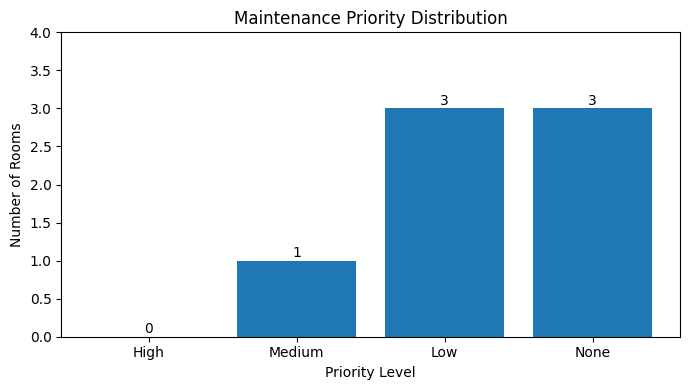

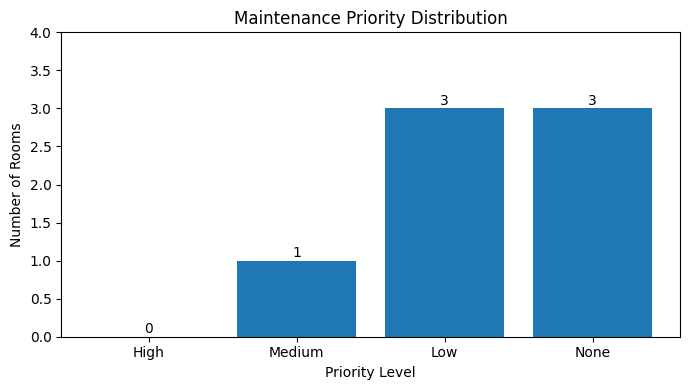

In [ ]:
priority_chart = create_priority_chart()

priority_chart

### Create an Inspection Issue Chart

This function summarizes the number of carpet, furniture, cleaning, and safety issues identified across all saved inspection records.

In [ ]:
def create_issue_chart():
    df = pd.read_csv(
        csv_path,
        keep_default_na=False
    )

    issue_counts = {
        "Carpet": df[
            df["carpet_condition"].isin(
                ["Stained", "Damaged"]
            )
        ].shape[0],

        "Furniture": df[
            df["furniture_condition"].isin(
                ["Minor Issue", "Damaged", "Missing"]
            )
        ].shape[0],

        "Cleaning": df[
            df["cleanliness"] == "Needs Cleaning"
        ].shape[0],

        "Safety": df[
            df["safety_issue"] == "Issue Identified"
        ].shape[0]
    }

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        issue_counts.keys(),
        issue_counts.values()
    )

    ax.set_title("Inspection Issues by Category")
    ax.set_xlabel("Issue Category")
    ax.set_ylabel("Number of Rooms")

    maximum = max(issue_counts.values())

    ax.set_ylim(
        0,
        maximum + 1
    )

    for i, value in enumerate(issue_counts.values()):
        ax.text(
            i,
            value + 0.05,
            str(value),
            ha="center"
        )

    fig.tight_layout()

    return fig

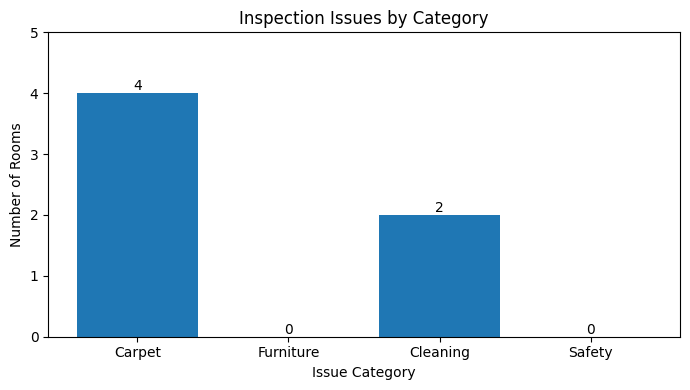

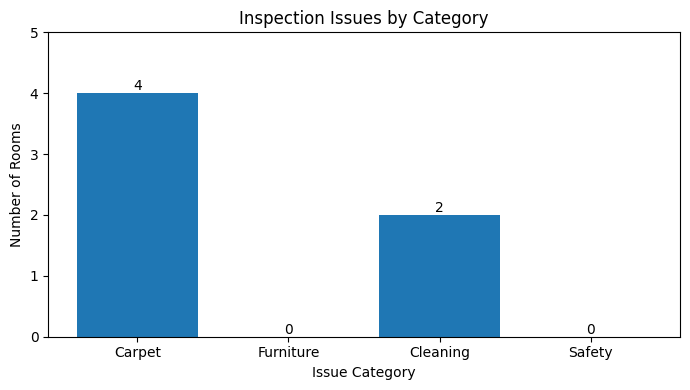

In [ ]:
issue_chart = create_issue_chart()

issue_chart

### Create the Building Dashboard Function

This function refreshes the building summary and both visualizations whenever the user requests the latest building analytics.

In [ ]:
def ui_show_building_dashboard():
    summary_df = get_building_summary()

    priority_fig = create_priority_chart()
    issue_fig = create_issue_chart()

    return (
        gr.update(
            value=summary_df,
            visible=True
        ),
        gr.update(
            value=priority_fig,
            visible=True
        ),
        gr.update(
            value=issue_fig,
            visible=True
        )
    )

## 39. Add an Inspection History Table

This section adds a searchable inspection-history view to the Facilities Inspection Agent. The history table allows users to review individual saved room inspections alongside the building-level analytics.

### Create the Inspection History Function

This function loads the latest inspection records from persistent storage and returns the most useful fields in a readable table.

In [ ]:
def get_inspection_history():
    if not os.path.exists(csv_path):
        return pd.DataFrame(
            columns=[
                "Building",
                "Room",
                "Occupancy",
                "Carpet",
                "Furniture",
                "Cleanliness",
                "Safety",
                "Maintenance Required",
                "Priority"
            ]
        )

    df = pd.read_csv(
        csv_path,
        keep_default_na=False
    )

    if df.empty:
        return pd.DataFrame(
            columns=[
                "Building",
                "Room",
                "Occupancy",
                "Carpet",
                "Furniture",
                "Cleanliness",
                "Safety",
                "Maintenance Required",
                "Priority"
            ]
        )

    history_df = df[
        [
            "building",
            "room",
            "occupancy_status",
            "carpet_condition",
            "furniture_condition",
            "cleanliness",
            "safety_issue",
            "maintenance_required",
            "priority"
        ]
    ].copy()

    history_df.columns = [
        "Building",
        "Room",
        "Occupancy",
        "Carpet",
        "Furniture",
        "Cleanliness",
        "Safety",
        "Maintenance Required",
        "Priority"
    ]

    history_df = history_df.sort_values(
        by=["Building", "Room"]
    )

    return history_df

### Test the Inspection History

This step confirms that saved inspection records can be loaded from the persistent CSV and displayed in a readable room-level table.

In [ ]:
get_inspection_history()

,Building,Room,Occupancy,Carpet,Furniture,Cleanliness,Safety,Maintenance Required,Priority
1,FSK,203,Vacant,Good,Good,Clean,None,False,None
2,FSK,204,Vacant,Good,Good,Clean,None,False,None
3,FSK,305,Vacant,Good,Good,Clean,None,False,None
4,FSK,307,Vacant,Stained,Good,Needs Cleaning,None,True,Low
5,FSK,308,Vacant,Damaged,Good,Needs Cleaning,None,True,Medium
6,FSK,309,Vacant,Stained,Good,Clean,None,True,Low
0,FSK,412,Vacant,Stained,Good,Clean,None,True,Low


### Connect Inspection History to the Interface

This function refreshes the inspection-history table whenever the user requests the latest saved records.

In [ ]:
def ui_show_inspection_history():
    history_df = get_inspection_history()

    return gr.update(
        value=history_df,
        visible=True
    )

## 40. Document the Project and Responsible-AI Design

This section documents the purpose, architecture, evaluation results, safeguards, and current limitations of the Facilities Inspection Agent. The goal is to make the design decisions behind the system clear and to avoid overstating the reliability of the prototype.

### Project Overview

The Facilities Inspection Agent is an AI-assisted workflow designed to reduce repetitive manual data entry and improve consistency in facilities inspection documentation.

Inspectors can enter observations in natural language rather than manually completing standardized fields. The system uses an LLM to extract structured inspection information, identifies missing details, requests follow-up information when necessary, and prepares a completed record for human review.

After the inspector confirms the final record, the inspection is validated, checked for duplicates, and saved to persistent storage. Saved inspection records are also used to generate building-level summaries, issue counts, maintenance priorities, charts, and inspection-history tables.

### System Workflow

The Facilities Inspection Agent follows this general workflow:

1. Inspector enters natural-language inspection notes.
2. The LLM converts the notes into standardized inspection fields.
3. Python validation checks whether the extracted values follow the approved categories.
4. Deterministic Python rules determine whether maintenance is required and assign a maintenance priority.
5. The system identifies any required fields that remain unknown.
6. If information is missing, the agent generates a follow-up request.
7. The inspector provides additional information in natural language.
8. The LLM updates only the previously missing fields.
9. The completed structured record is presented to the inspector for human review.
10. The inspector explicitly confirms the record before saving.
11. Duplicate protection checks whether the same building and room already exist.
12. The approved record is saved to a persistent CSV file.
13. Saved records are used to generate building-level analytics and inspection history.

### Division of AI and Deterministic Responsibilities

The system intentionally separates tasks that benefit from language understanding from tasks that should remain predictable and deterministic.

**LLM responsibilities:**
- Interpret natural-language inspection notes
- Extract standardized inspection information
- Interpret follow-up responses
- Handle variations in inspector wording

**Python responsibilities:**
- Validate standardized values
- Determine whether maintenance is required
- Assign maintenance priority
- Identify missing required fields
- Generate follow-up field lists
- Check for duplicate records
- Save inspection records
- Calculate building statistics
- Produce analytics and visualizations

This separation reduces reliance on the LLM for calculations and operational decisions that can be handled more consistently with explicit rules.

### Responsible-AI Safeguards

Several safeguards were incorporated into the prototype:

- **No unsupported assumptions:** Conditions that are not mentioned by the inspector are classified as "Unknown" rather than assumed to be satisfactory.
- **Standardized categories:** The LLM is restricted to predefined values for occupancy, carpet condition, furniture condition, cleanliness, and safety.
- **Validation:** Python checks AI-generated values before records can be saved.
- **Deterministic maintenance rules:** Maintenance requirements and priority levels are calculated using explicit Python rules rather than generated by the LLM.
- **Missing-information detection:** Incomplete records trigger follow-up questions instead of being silently treated as complete.
- **Human review:** Completed records must be reviewed and explicitly confirmed by the inspector before being saved.
- **Duplicate protection:** Existing building-room combinations are checked before new records are stored.
- **Audit trail:** Original inspection notes and follow-up information are preserved alongside standardized records.
- **Persistent source data:** Saved inspection records are stored separately from the model so analytics can be calculated from structured data rather than regenerated by AI.

### Evaluation Results

The extraction workflow was evaluated using several small test sets.

**Initial development evaluation**
- 11 inspection notes
- 5 standardized fields evaluated per inspection
- 55 total field comparisons
- 55 correct
- 100.0% field-level accuracy

**Holdout evaluation**
- 8 new and more challenging inspection notes
- 40 total field comparisons
- 39 correct
- 97.5% field-level accuracy

The holdout error occurred when the note stated that a smoke detector "appears normal." The system returned "Unknown" for the safety field instead of the expected value "None."

The extraction instructions were revised to better distinguish between an unobserved safety condition and a safety item that was explicitly inspected and found to be normal.

**Safety-focused evaluation after revision**
- 6 new safety-focused inspection notes
- 6 correct classifications
- 100.0% accuracy on this small safety-focused test set

These results describe performance only on the specific test cases evaluated and should not be interpreted as evidence that the system will achieve the same accuracy on all real-world inspections.

### Current Limitations

This project is a prototype and has several limitations:

- The evaluation datasets are small and primarily synthetic.
- The system has not yet been evaluated on a large set of real facilities inspection notes.
- LLM outputs can vary, so human review remains necessary.
- The current maintenance and priority rules are simplified and would need to be aligned with an organization's actual facilities policies.
- The prototype stores records in a CSV file rather than a production database.
- User authentication and role-based permissions are not implemented.
- The current interface is designed for demonstration rather than production deployment.
- The prototype has not yet undergone formal testing with facilities employees or other real end users.

### Project Outcome

The prototype demonstrates how an LLM can support facilities inspection documentation without replacing deterministic business rules or human oversight.

The system combines natural-language processing, structured data extraction, validation, multi-step follow-up workflows, persistent storage, human confirmation, and building-level analytics into one end-to-end application.

The project was designed around a real operational problem: reducing repetitive manual inspection documentation while improving consistency and making the resulting data easier to analyze.

## 41. Allow Human Editing Before Confirmation

This section allows the inspector to manually correct the standardized inspection fields before the record is saved. Any edits made during human review are applied to the structured record, and maintenance requirements and priority levels are recalculated automatically before confirmation.

### Create a Standardized Summary Function

This function creates an updated summary from the final structured inspection fields. The summary is regenerated whenever the inspector applies manual edits.

In [ ]:
def create_standardized_summary(record):
    return (
        f"{record['building']} {record['room']} | "
        f"Occupancy: {record['occupancy_status']} | "
        f"Carpet: {record['carpet_condition']} | "
        f"Furniture: {record['furniture_condition']} | "
        f"Cleanliness: {record['cleanliness']} | "
        f"Safety: {record['safety_issue']}."
    )

### Create the Manual-Edit Function

This function applies inspector corrections to the structured record. After the edits are applied, deterministic Python rules recalculate maintenance requirements and priority, and the standardized summary is refreshed.

In [ ]:
def apply_manual_edits(
    record,
    building,
    room,
    occupancy_status,
    carpet_condition,
    furniture_condition,
    cleanliness,
    safety_issue
):
    if record is None:
        return None

    updated_record = record.copy()

    updated_record["building"] = building
    updated_record["room"] = room
    updated_record["occupancy_status"] = occupancy_status
    updated_record["carpet_condition"] = carpet_condition
    updated_record["furniture_condition"] = furniture_condition
    updated_record["cleanliness"] = cleanliness
    updated_record["safety_issue"] = safety_issue

    # Recalculate deterministic fields
    updated_record["maintenance_required"] = determine_maintenance(
        updated_record
    )

    updated_record["priority"] = determine_priority(
        updated_record
    )

    # Refresh the summary
    updated_record["summary"] = create_standardized_summary(
        updated_record
    )

    return updated_record

### Connect Manual Editing to the User Interface

These functions populate the editable review fields with the AI-generated inspection values and apply any corrections made by the inspector.

In [ ]:
def populate_review_fields(record):
    if record is None:
        return (
            "",
            "",
            "Unknown",
            "Unknown",
            "Unknown",
            "Unknown",
            "Unknown"
        )

    return (
        record["building"],
        record["room"],
        record["occupancy_status"],
        record["carpet_condition"],
        record["furniture_condition"],
        record["cleanliness"],
        record["safety_issue"]
    )

In [ ]:
def ui_apply_manual_edits(
    record,
    building,
    room,
    occupancy_status,
    carpet_condition,
    furniture_condition,
    cleanliness,
    safety_issue
):
    updated_record = apply_manual_edits(
        record,
        building,
        room,
        occupancy_status,
        carpet_condition,
        furniture_condition,
        cleanliness,
        safety_issue
    )

    errors = validate_record(updated_record)

    if len(errors) > 0:
        return (
            "The edited record contains validation errors.",
            format_record(updated_record),
            updated_record
        )

    missing_fields = check_missing_fields(updated_record)

    if len(missing_fields) > 0:
        return (
            "The edited record still contains missing required information.",
            format_record(updated_record),
            updated_record
        )

    return (
        "Edits applied successfully. Review the updated record and confirm when ready.",
        format_record(updated_record),
        updated_record
    )

## 42. Automatically Generate Maintenance Work Orders

This section creates maintenance work orders from confirmed inspection records. When an inspection requires maintenance, the system generates a structured work order and stores it separately from the inspection history.

### Define Work-Order Storage

Maintenance work orders are stored in a separate persistent CSV file in Google Drive so inspection records and maintenance tasks can be managed independently.

In [ ]:
work_order_csv_path = (
    "/content/drive/MyDrive/facilities_work_orders.csv"
)

### Identify Maintenance Issue Categories

This function identifies which facilities categories require follow-up based on the confirmed structured inspection record.

In [ ]:
def identify_work_order_categories(record):
    categories = []

    if record["carpet_condition"] in [
        "Stained",
        "Damaged"
    ]:
        categories.append("Carpet")

    if record["furniture_condition"] in [
        "Minor Issue",
        "Damaged",
        "Missing"
    ]:
        categories.append("Furniture")

    if record["cleanliness"] == "Needs Cleaning":
        categories.append("Cleaning")

    if record["safety_issue"] == "Issue Identified":
        categories.append("Safety")

    return categories

### Generate a Maintenance Work Order

This function converts a confirmed inspection requiring maintenance into a structured work order. The work order includes the building, room, issue categories, priority, source inspection information, and status.

In [ ]:
from datetime import datetime

def generate_work_order(record):

    maintenance_required = (
        str(record["maintenance_required"])
        .lower()
        == "true"
    )

    # Do not create a work order if maintenance is not needed
    if not maintenance_required:
        return None

    categories = identify_work_order_categories(record)

    work_order = {
        "work_order_id": (
            f"WO-{record['building']}-{record['room']}"
        ),
        "building": record["building"],
        "room": record["room"],
        "category": ", ".join(categories),
        "priority": record["priority"],
        "issue_description": record["summary"],
        "source": "Facilities Inspection Agent",
        "status": "Open",
        "created_at": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    }

    return work_order

### Test Work-Order Generation

This test confirms that an inspection requiring maintenance produces a structured work order.

In [ ]:
test_work_order = generate_work_order(
    final_agent_record
)

test_work_order

{'work_order_id': 'WO-FSK-307',
 'building': 'FSK',
 'room': '307',
 'category': 'Carpet, Cleaning',
 'priority': 'Low',
 'issue_description': 'FSK 307 is vacant. The carpet is stained near the doorway.',
 'source': 'Facilities Inspection Agent',
 'status': 'Open',
 'created_at': '2026-09-22 23:55:31'}

### Create the Work-Order Save Tool

This function saves generated maintenance work orders to persistent storage while preventing duplicate work orders for the same inspection.

In [ ]:
def save_work_order(work_order):

    if work_order is None:
        return {
            "created": False,
            "message": "No maintenance work order is required."
        }

    # Load existing work orders if the file already exists
    if os.path.exists(work_order_csv_path):
        work_orders_df = pd.read_csv(
            work_order_csv_path,
            keep_default_na=False
        )

        # Prevent duplicate work-order IDs
        if (
            work_order["work_order_id"]
            in work_orders_df["work_order_id"].astype(str).values
        ):
            return {
                "created": False,
                "message": "A work order already exists for this inspection."
            }

    else:
        work_orders_df = pd.DataFrame()

    new_work_order_df = pd.DataFrame(
        [work_order]
    )

    updated_work_orders_df = pd.concat(
        [
            work_orders_df,
            new_work_order_df
        ],
        ignore_index=True
    )

    updated_work_orders_df.to_csv(
        work_order_csv_path,
        index=False
    )

    return {
        "created": True,
        "message": "Maintenance work order created successfully.",
        "work_order": work_order
    }

### Test Saving a Maintenance Work Order

This test confirms that a generated work order can be saved to persistent storage.

In [ ]:
work_order_save_result = save_work_order(
    test_work_order
)

print(work_order_save_result)

{'created': True, 'message': 'Maintenance work order created successfully.', 'work_order': {'work_order_id': 'WO-FSK-307', 'building': 'FSK', 'room': '307', 'category': 'Carpet, Cleaning', 'priority': 'Low', 'issue_description': 'FSK 307 is vacant. The carpet is stained near the doorway.', 'source': 'Facilities Inspection Agent', 'status': 'Open', 'created_at': '2026-09-22 23:55:31'}}


### View Saved Maintenance Work Orders

This step loads the persistent work-order dataset so generated maintenance tasks can be reviewed.

In [ ]:
work_orders_df = pd.read_csv(
    work_order_csv_path,
    keep_default_na=False
)

work_orders_df

,work_order_id,building,room,category,priority,issue_description,source,status,created_at
0,WO-FSK-307,FSK,307,"Carpet, Cleaning",Low,FSK 307 is vacant. The carpet is stained near ...,Facilities Inspection Agent,Open,2026-09-22 23:55:31


### Connect Work-Order Generation to Inspection Confirmation

This version of the confirmation function saves the approved inspection and automatically creates a maintenance work order when the final record requires maintenance.

## 43. Track and Update Maintenance Work Orders

This section adds maintenance work-order tracking to the Facilities Inspection Agent. Supervisors can review generated work orders and update their status as maintenance work progresses from Open to In Progress to Completed.

### Define Allowed Work-Order Statuses

This step defines the standardized status values that can be assigned to maintenance work orders.

In [ ]:
valid_work_order_statuses = [
    "Open",
    "In Progress",
    "Completed"
]

### Create the Work-Order History Function

This function loads all saved maintenance work orders from persistent storage and displays them in a readable table.

In [ ]:
def get_work_order_history():
    columns = [
        "Work Order ID",
        "Building",
        "Room",
        "Category",
        "Priority",
        "Issue Description",
        "Status",
        "Created At",
        "Updated At",
        "Completed At"
    ]

    if not os.path.exists(work_order_csv_path):
        return pd.DataFrame(columns=columns)

    df = pd.read_csv(
        work_order_csv_path,
        keep_default_na=False
    )

    # Add tracking columns if older records do not have them yet
    if "updated_at" not in df.columns:
        df["updated_at"] = ""

    if "completed_at" not in df.columns:
        df["completed_at"] = ""

    history_df = df[
        [
            "work_order_id",
            "building",
            "room",
            "category",
            "priority",
            "issue_description",
            "status",
            "created_at",
            "updated_at",
            "completed_at"
        ]
    ].copy()

    history_df.columns = columns

    return history_df

### Test the Work-Order History

This step confirms that previously generated maintenance work orders can be loaded from persistent storage.

In [ ]:
get_work_order_history()

,Work Order ID,Building,Room,Category,Priority,Issue Description,Status,Created At,Updated At,Completed At
0,WO-FSK-307,FSK,307,"Carpet, Cleaning",Low,FSK 307 is vacant. The carpet is stained near ...,Open,2026-09-22 23:55:31,,
1,WO-FSK-311,FSK,311,Carpet,Medium,FSK 311 is vacant. Carpet is damaged near the ...,Open,2026-09-23 00:01:24,,


### Create the Work-Order Status Update Tool

This function updates the status of an existing maintenance work order. It records when the work order was last updated and records a completion timestamp when the status changes to Completed.

In [ ]:
def update_work_order_status(work_order_id, new_status):

    # Validate the requested status
    if new_status not in valid_work_order_statuses:
        return {
            "updated": False,
            "message": "Invalid work-order status."
        }

    # Make sure the work-order file exists
    if not os.path.exists(work_order_csv_path):
        return {
            "updated": False,
            "message": "No maintenance work orders were found."
        }

    df = pd.read_csv(
        work_order_csv_path,
        keep_default_na=False
    )

    # Add tracking columns if needed
    if "updated_at" not in df.columns:
        df["updated_at"] = ""

    if "completed_at" not in df.columns:
        df["completed_at"] = ""

    # Find the selected work order
    matching_rows = (
        df["work_order_id"].astype(str)
        == str(work_order_id)
    )

    if not matching_rows.any():
        return {
            "updated": False,
            "message": "Work order was not found."
        }

    current_time = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    # Update status
    df.loc[
        matching_rows,
        "status"
    ] = new_status

    # Record update time
    df.loc[
        matching_rows,
        "updated_at"
    ] = current_time

    # Record completion time
    if new_status == "Completed":
        df.loc[
            matching_rows,
            "completed_at"
        ] = current_time
    else:
        df.loc[
            matching_rows,
            "completed_at"
        ] = ""

    # Save changes
    df.to_csv(
        work_order_csv_path,
        index=False
    )

    return {
        "updated": True,
        "message": (
            f"{work_order_id} updated to {new_status}."
        )
    }

### Test a Work-Order Status Update

This test changes an existing maintenance work order from Open to In Progress and confirms that the change is written to persistent storage.

In [ ]:
status_update_result = update_work_order_status(
    "WO-FSK-311",
    "In Progress"
)

print(status_update_result)

{'updated': True, 'message': 'WO-FSK-311 updated to In Progress.'}


In [ ]:
get_work_order_history()

,Work Order ID,Building,Room,Category,Priority,Issue Description,Status,Created At,Updated At,Completed At
0,WO-FSK-307,FSK,307,"Carpet, Cleaning",Low,FSK 307 is vacant. The carpet is stained near ...,Open,2026-09-22 23:55:31,,
1,WO-FSK-311,FSK,311,Carpet,Medium,FSK 311 is vacant. Carpet is damaged near the ...,In Progress,2026-09-23 00:01:24,2026-09-23 00:09:46,


### Create a Work-Order Selection Helper

This function retrieves the IDs of all existing maintenance work orders so they can be selected from the user interface.

In [ ]:
def get_work_order_ids():
    if not os.path.exists(work_order_csv_path):
        return []

    df = pd.read_csv(
        work_order_csv_path,
        keep_default_na=False
    )

    if df.empty:
        return []

    return df["work_order_id"].astype(str).tolist()

### Create the Work-Order Refresh Function

This function refreshes both the maintenance work-order table and the list of selectable work orders.

In [ ]:
def ui_refresh_work_orders():

    history_df = get_work_order_history()
    work_order_ids = get_work_order_ids()

    if len(work_order_ids) > 0:
        selected_id = work_order_ids[0]
    else:
        selected_id = None

    return (
        gr.update(
            value=history_df,
            visible=True
        ),
        gr.update(
            choices=work_order_ids,
            value=selected_id
        )
    )

### Connect Status Updates to the Interface

This function applies a supervisor's selected status change and refreshes the work-order history table after the update.

In [ ]:
def ui_update_work_order_status(
    work_order_id,
    new_status
):
    if not work_order_id:
        return (
            "Please select a work order.",
            get_work_order_history()
        )

    result = update_work_order_status(
        work_order_id,
        new_status
    )

    return (
        result["message"],
        get_work_order_history()
    )

## 44. Run a Final End-to-End System Test

This section validates the completed Facilities Inspection Agent using a new inspection from beginning to end. The test covers AI extraction, follow-up interaction, human correction, deterministic maintenance rules, persistent saving, work-order generation, and work-order status tracking.

### Step 1: Process a New Inspection

A new incomplete inspection is submitted to confirm that the agent can extract available information and identify missing required fields.

In [ ]:
final_test_start = start_inspection_for_review(
    "FSK 313 vacant. Carpet is stained near the window."
)

print("Status:", final_test_start["status"])
print("Message:", final_test_start["message"])
print("Missing fields:", final_test_start["missing_fields"])

Status: Needs Follow-Up
Message: Please provide the furniture condition, cleanliness, and safety condition.
Missing fields: ['furniture_condition', 'cleanliness', 'safety_issue']


### Step 2: Review the Initial AI Extraction

This step reviews the structured information extracted from the initial inspection before additional information is provided.

In [ ]:
final_test_start["record"]

{'building': 'FSK',
 'room': '313',
 'occupancy_status': 'Vacant',
 'carpet_condition': 'Stained',
 'furniture_condition': 'Unknown',
 'cleanliness': 'Unknown',
 'safety_issue': 'Unknown',
 'summary': 'FSK 313 is vacant. The carpet is stained near the window.',
 'original_notes': 'FSK 313 vacant. Carpet is stained near the window.',
 'maintenance_required': True,
 'priority': 'Low'}

### Step 3: Provide Follow-Up Information

The inspector provides the missing information in natural language. The agent updates only the previously incomplete fields.

In [ ]:
final_test_followup = continue_inspection_for_review(
    final_test_start["record"],
    "Furniture is in good condition. The room needs cleaning. No safety concerns."
)

print("Status:", final_test_followup["status"])
print("Message:", final_test_followup["message"])

Status: Ready for Review
Message: Inspection is complete. Please review the record before saving.


### Step 4: Review the Completed Record

This step reviews the completed AI-assisted inspection before any human corrections or confirmation are applied.

In [ ]:
final_review_record = final_test_followup["record"]

final_review_record

{'building': 'FSK',
 'room': '313',
 'occupancy_status': 'Vacant',
 'carpet_condition': 'Stained',
 'furniture_condition': 'Good',
 'cleanliness': 'Needs Cleaning',
 'safety_issue': 'None',
 'summary': 'FSK 313 is vacant. The carpet is stained near the window.',
 'original_notes': 'FSK 313 vacant. Carpet is stained near the window. Follow-up: Furniture is in good condition. The room needs cleaning. No safety concerns.',
 'maintenance_required': True,
 'priority': 'Low'}

### Step 5: Apply a Human Correction

During human review, the inspector determines that the carpet condition should be classified as "Damaged" rather than "Stained." The corrected value is applied before the record is saved.

In [ ]:
final_corrected_record = apply_manual_edits(
    final_review_record,
    final_review_record["building"],
    final_review_record["room"],
    final_review_record["occupancy_status"],
    "Damaged",
    final_review_record["furniture_condition"],
    final_review_record["cleanliness"],
    final_review_record["safety_issue"]
)

final_corrected_record

{'building': 'FSK',
 'room': '313',
 'occupancy_status': 'Vacant',
 'carpet_condition': 'Damaged',
 'furniture_condition': 'Good',
 'cleanliness': 'Needs Cleaning',
 'safety_issue': 'None',
 'summary': 'FSK 313 | Occupancy: Vacant | Carpet: Damaged | Furniture: Good | Cleanliness: Needs Cleaning | Safety: None.',
 'original_notes': 'FSK 313 vacant. Carpet is stained near the window. Follow-up: Furniture is in good condition. The room needs cleaning. No safety concerns.',
 'maintenance_required': True,
 'priority': 'Medium'}

In [ ]:
print(
    "Carpet:",
    final_corrected_record["carpet_condition"]
)

print(
    "Maintenance Required:",
    final_corrected_record["maintenance_required"]
)

print(
    "Priority:",
    final_corrected_record["priority"]
)

Carpet: Damaged
Maintenance Required: True
Priority: Medium


### Step 6: Validate the Final Record

Before saving, the corrected inspection record is checked for standardized values and missing required information.

In [ ]:
final_validation_errors = validate_record(
    final_corrected_record
)

final_missing_fields = check_missing_fields(
    final_corrected_record
)

print(
    "Validation errors:",
    final_validation_errors
)

print(
    "Missing fields:",
    final_missing_fields
)

Validation errors: []
Missing fields: []


### Step 7: Save the Human-Confirmed Inspection

After successful review and validation, the final inspection record is saved to persistent storage.

In [ ]:
final_save_result = save_inspection(
    final_corrected_record
)

print(final_save_result)

{'saved': True, 'message': 'Inspection record saved successfully and CSV updated.', 'building': 'FSK', 'room': '313'}


### Step 8: Generate the Maintenance Work Order

Because the confirmed inspection requires maintenance, the system generates a structured maintenance work order from the final approved record.

In [ ]:
final_work_order = generate_work_order(
    final_corrected_record
)

final_work_order

{'work_order_id': 'WO-FSK-313',
 'building': 'FSK',
 'room': '313',
 'category': 'Carpet, Cleaning',
 'priority': 'Medium',
 'issue_description': 'FSK 313 | Occupancy: Vacant | Carpet: Damaged | Furniture: Good | Cleanliness: Needs Cleaning | Safety: None.',
 'source': 'Facilities Inspection Agent',
 'status': 'Open',
 'created_at': '2026-09-23 00:26:58'}

### Step 9: Save the Maintenance Work Order

The generated work order is saved to the persistent maintenance dataset.

In [ ]:
final_work_order_result = save_work_order(
    final_work_order
)

print(final_work_order_result)

{'created': True, 'message': 'Maintenance work order created successfully.', 'work_order': {'work_order_id': 'WO-FSK-313', 'building': 'FSK', 'room': '313', 'category': 'Carpet, Cleaning', 'priority': 'Medium', 'issue_description': 'FSK 313 | Occupancy: Vacant | Carpet: Damaged | Furniture: Good | Cleanliness: Needs Cleaning | Safety: None.', 'source': 'Facilities Inspection Agent', 'status': 'Open', 'created_at': '2026-09-23 00:26:58'}}


### Step 10: Verify Persistent Inspection Storage

This step reloads the inspection dataset and verifies that Room 313 was permanently added.

In [ ]:
final_inspection_check = pd.read_csv(
    csv_path,
    keep_default_na=False
)

final_inspection_check[
    final_inspection_check["room"]
    .astype(str)
    == "313"
]

,building,room,occupancy_status,carpet_condition,furniture_condition,cleanliness,safety_issue,summary,original_notes,maintenance_required,priority
10,FSK,313,Vacant,Damaged,Good,Needs Cleaning,None,FSK 313 | Occupancy: Vacant | Carpet: Damaged ...,FSK 313 vacant. Carpet is stained near the win...,True,Medium


### Step 11: Verify Persistent Work-Order Storage

This step confirms that the Room 313 maintenance work order was successfully stored.

In [ ]:
final_work_order_check = pd.read_csv(
    work_order_csv_path,
    keep_default_na=False
)

final_work_order_check[
    final_work_order_check["work_order_id"]
    == "WO-FSK-313"
]

,work_order_id,building,room,category,priority,issue_description,source,status,created_at,updated_at,completed_at
3,WO-FSK-313,FSK,313,"Carpet, Cleaning",Medium,FSK 313 | Occupancy: Vacant | Carpet: Damaged ...,Facilities Inspection Agent,Open,2026-09-23 00:26:58,,


### Step 12: Test Work-Order Status Progression

The new maintenance work order is moved from Open to In Progress to confirm that status tracking functions correctly.

In [ ]:
final_status_update = update_work_order_status(
    "WO-FSK-313",
    "In Progress"
)

print(final_status_update)

{'updated': True, 'message': 'WO-FSK-313 updated to In Progress.'}


In [ ]:
get_work_order_history()

,Work Order ID,Building,Room,Category,Priority,Issue Description,Status,Created At,Updated At,Completed At
0,WO-FSK-307,FSK,307,"Carpet, Cleaning",Low,FSK 307 is vacant. The carpet is stained near ...,Completed,2026-09-22 23:55:31,2026-09-23 00:15:21,2026-09-23 00:15:21
1,WO-FSK-311,FSK,311,Carpet,Medium,FSK 311 is vacant. Carpet is damaged near the ...,In Progress,2026-09-23 00:01:24,2026-09-23 00:09:46,
2,WO-Shenkman Hall-615,Shenkman Hall,615,"Carpet, Cleaning",Medium,"Room 615 in Shenkman Hall is vacant, with some...",Completed,2026-09-23 00:19:10,2026-09-23 00:21:08,2026-09-23 00:21:08
3,WO-FSK-313,FSK,313,"Carpet, Cleaning",Medium,FSK 313 | Occupancy: Vacant | Carpet: Damaged ...,In Progress,2026-09-23 00:26:58,2026-09-23 00:28:47,


### Step 13: Confirm the Analytics Updated

This step verifies that the newly saved inspection is automatically incorporated into the building-level analytics.

In [ ]:
get_building_summary()

,Metric,Value
0,Building,"FSK, Shenkman Hall"
1,Rooms Inspected,11
2,Maintenance Required,8
3,No Maintenance Required,3
4,High Priority,0
5,Medium Priority,5
6,Low Priority,3
7,Carpet Issues,8
8,Furniture Issues,0
9,Cleaning Issues,4


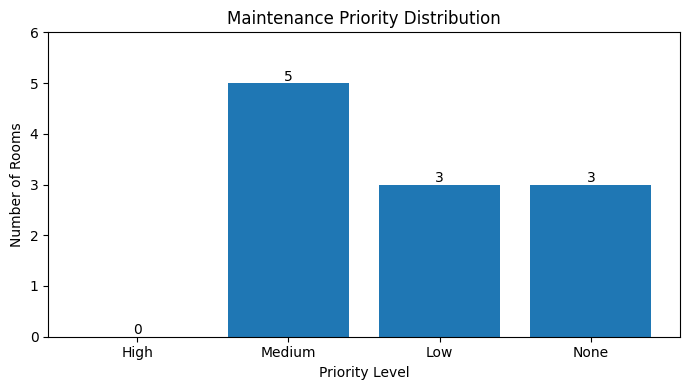

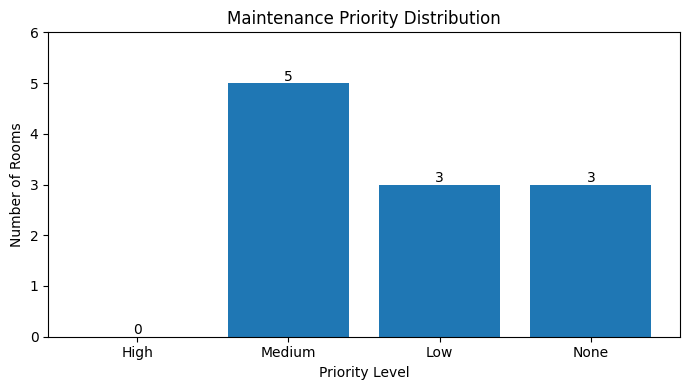

In [ ]:
create_priority_chart()

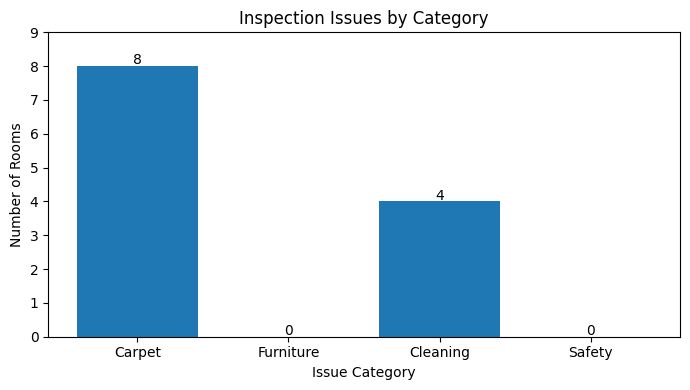

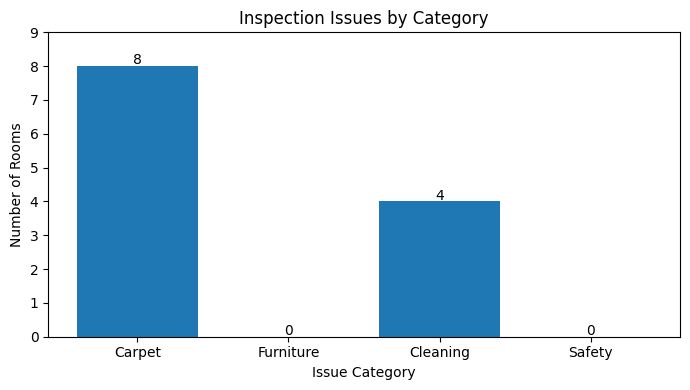

In [ ]:
create_issue_chart()

### Final End-to-End Test Result

The completed Facilities Inspection Agent successfully processed a new inspection through the entire workflow:

- Natural-language inspection information was converted into standardized structured data.
- Missing information was detected automatically.
- Additional information was collected through a follow-up interaction.
- The completed record was presented for human review.
- A human correction was applied before saving.
- Maintenance requirements and priority were recalculated automatically after the correction.
- The final record passed validation and completeness checks.
- The confirmed inspection was stored in persistent inspection history.
- A maintenance work order was generated and saved automatically.
- The work order was successfully moved from Open to In Progress.
- The new inspection was incorporated into the building-level analytics.

This test demonstrates the complete workflow from field observation through documentation, human oversight, maintenance follow-up, persistent storage, and operational analytics.